## Libraries and data loading 📚

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import aquarel
import scipy.stats as st
import wordcloud as wc
import bar_chart_race as bcr
import scipy.stats as st
import pyalex as alex
from ineqpy.inequality import gini
from IPython.display import clear_output
import polars as pl
alex.config.email = "gabriel.vignon@ensta.fr"
sns.set_palette("viridis")

In [2]:
works = pl.read_csv("data_pharmacology/data.csv")
works = works.filter(pl.col("year") != 2025)

In [3]:
works

,title,year,cited_by_count,countries_distinct_count,institutions_distinct_count,citation_normalized_percentile,primary_topic,keywords,concepts,referenced_works_count,referenced_works,abstract,abstract_inverted_index,author_1,author_2,author_3,institution_1,country_1,cited_by_count_2025,cited_by_count_2024,cited_by_count_2023,cited_by_count_2022,cited_by_count_2021,cited_by_count_2020,cited_by_count_2019,cited_by_count_2018,cited_by_count_2017,cited_by_count_2016,cited_by_count_2015,cited_by_count_2014,cited_by_count_2013,cited_by_count_2012,primary_subfield,primary_field,primary_domain,keyword_1,…,country_157,country_158,country_159,country_160,country_161,country_162,country_163,country_164,country_165,keyword_13,country_166,country_167,country_168,country_169,country_170,country_171,country_172,country_173,country_174,country_175,country_176,country_177,country_178,country_179,country_180,country_181,country_182,country_183,country_184,country_185,country_186,country_187,country_188,country_189,country_190,country_191,country_192
i64,str,i64,i64,i64,i64,str,str,str,str,i64,str,str,str,str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,…,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
0,"""Nitric oxide: physiology, path…",1991,15648,1,1,"""{'value': 0.997271, 'is_in_top…","""('Nitric Oxide and Endothelin …","""[{'id': 'https://openalex.org/…","""[{'id': 'https://openalex.org/…",0,"""[]""",null,null,"""https://openalex.org/A50053578…","""https://openalex.org/A50561992…","""https://openalex.org/A50034300…","""['Wellcome Trust', 'https://op…","""GB""",32.0,54.0,114.0,112.0,129.0,168.0,180.0,208.0,242.0,278.0,319.0,403.0,400.0,485.0,"""('Physiology',)""","""('Medicine',)""","""('Health Sciences',)""","""Pathophysiology""",…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
1,"""International Union of Pharmac…",2003,7170,4,9,"""{'value': 0.69256, 'is_in_top_…","""('Nicotinic Acetylcholine Rece…","""[{'id': 'https://openalex.org/…","""[{'id': 'https://openalex.org/…",3,"""['https://openalex.org/W200713…","""This issue of Pharmacological …","""{'This': [0], 'issue': [1], 'o…","""https://openalex.org/A50789417…","""https://openalex.org/A50435673…","""https://openalex.org/A50377188…","""['National Institute on Aging'…","""DE""",null,1.0,null,null,20.0,14.0,22.0,14.0,19.0,30.0,296.0,571.0,685.0,724.0,"""('Molecular Biology',)""","""('Biochemistry, Genetics and M…","""('Life Sciences',)""","""Clinical Pharmacology""",…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
2,"""Theoretical Basis, Experimenta…",2006,4825,1,1,"""{'value': 0.992754, 'is_in_top…","""('Free Radicals and Antioxidan…","""[{'id': 'https://openalex.org/…","""[{'id': 'https://openalex.org/…",397,"""['https://openalex.org/W112108…","""The median-effect equation der…","""{'The': [0, 223, 248], 'median…","""https://openalex.org/A50262251…",null,null,"""['Memorial Sloan Kettering Can…","""US""",132.0,313.0,396.0,382.0,444.0,418.0,418.0,354.0,352.0,312.0,285.0,258.0,182.0,161.0,"""('Organic Chemistry',)""","""('Chemistry',)""","""('Physical Sciences',)""","""Plot (graphics)""",…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
3,"""The Effects of Plant Flavonoid…",2000,4728,1,1,"""{'value': 0.984496, 'is_in_top…","""('Phytochemicals and Antioxida…","""[{'id': 'https://openalex.org/…","""[{'id': 'https://openalex.org/…",1022,"""['https://openalex.org/W102315…","""Flavonoids are nearly ubiquito…","""{'Flavonoids': [0, 57], 'are':…","""htt

## General data preparation ⚒️

### General variables

In [12]:
year_begin = 1960
year_end = 2024

### Citation rate

In [13]:
works = works.with_columns(
    age=2025 - pl.col("year")
)

### MNCS

In [14]:
cbc_per_year = (
    works
    .select(
        [pl.col("year"), pl.col("cited_by_count"), pl.col("title")]
    )
    .group_by(
        pl.col("year"),
        maintain_order=True
    )
    .agg(
        pl.col("cited_by_count").mean().name.prefix("mean_")
    )
)

works = works.join(
    cbc_per_year,
    on="year",
    how="left"
)

works = (
    works
    .with_columns(
        mncs = pl.col("cited_by_count") / pl.col("mean_cited_by_count")
    )
    .drop("mean_cited_by_count")
)


### Number of authors

In [15]:
cols_authors = [col for col in works.columns if col.startswith("author_")]

works = works.with_columns(
    authors_count = sum(
        [pl.col(col).is_not_null().cast(pl.Int8) for col in cols_authors]
    )

)

In [16]:
works

,title,year,cited_by_count,countries_distinct_count,institutions_distinct_count,citation_normalized_percentile,primary_topic,keywords,concepts,referenced_works_count,referenced_works,abstract,abstract_inverted_index,author_1,author_2,author_3,institution_1,country_1,cited_by_count_2025,cited_by_count_2024,cited_by_count_2023,cited_by_count_2022,cited_by_count_2021,cited_by_count_2020,cited_by_count_2019,cited_by_count_2018,cited_by_count_2017,cited_by_count_2016,cited_by_count_2015,cited_by_count_2014,cited_by_count_2013,cited_by_count_2012,primary_subfield,primary_field,primary_domain,keyword_1,…,country_162,country_163,country_164,country_165,keyword_13,country_166,country_167,country_168,country_169,country_170,country_171,country_172,country_173,country_174,country_175,country_176,country_177,country_178,country_179,country_180,country_181,country_182,country_183,country_184,country_185,country_186,country_187,country_188,country_189,country_190,country_191,country_192,age,mncs,authors_count,review,meta_analysis
i64,str,i64,i64,i64,i64,str,str,str,str,i64,str,str,str,str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,…,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,f64,i8,bool,bool
0,"""nitric oxide: physiology, path…",1991,15648,1,1,"""{'value': 0.997271, 'is_in_top…","""('Nitric Oxide and Endothelin …","""[{'id': 'https://openalex.org/…","""[{'id': 'https://openalex.org/…",0,"""[]""","""""",null,"""https://openalex.org/A50053578…","""https://openalex.org/A50561992…","""https://openalex.org/A50034300…","""['Wellcome Trust', 'https://op…","""GB""",32.0,54.0,114.0,112.0,129.0,168.0,180.0,208.0,242.0,278.0,319.0,403.0,400.0,485.0,"""('Physiology',)""","""('Medicine',)""","""('Health Sciences',)""","""Pathophysiology""",…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,34,347.571069,3,false,false
1,"""international union of pharmac…",2003,7170,4,9,"""{'value': 0.69256, 'is_in_top_…","""('Nicotinic Acetylcholine Rece…","""[{'id': 'https://openalex.org/…","""[{'id': 'https://openalex.org/…",3,"""['https://openalex.org/W200713…","""this issue of pharmacological …","""{'This': [0], 'issue': [1], 'o…","""https://openalex.org/A50789417…","""https://openalex.org/A50435673…","""https://openalex.org/A50377188…","""['National Institute on Aging'…","""DE""",null,1.0,null,null,20.0,14.0,22.0,14.0,19.0,30.0,296.0,571.0,685.0,724.0,"""('Molecular Biology',)""","""('Biochemistry, Genetics and M…","""('Life Sciences',)""","""Clinical Pharmacology""",…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,22,102.888138,8,true,false
2,"""theoretical basis, experimenta…",2006,4825,1,1,"""{'value': 0.992754, 'is_in_top…","""('Free Radicals and Antioxidan…","""[{'id': 'https://openalex.org/…","""[{'id': 'https://openalex.org/…",397,"""['https://openalex.org/W112108…","""the median-effect equation der…","""{'The': [0, 223, 248], 'median…","""https://openalex.org/A50262251…",null,null,"""['Memorial Sloan Kettering Can…","""US""",132.0,313.0,396.0,382.0,444.0,418.0,418.0,354.0,352.0,312.0,285.0,258.0,182.0,161.0,"""('Organic Chemistry',)""","""('Chemistry',)""","""('Physical Sciences',)""","""Plot (graphics)""",…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,19,66.895721,1,true,false
3,"""the effects of plant flavonoid…",2000,4728,1,1,"""{'value': 0.984496, 'is_in_top…","""('Phytochemicals and Antioxida…","""[{'id': 'https://openalex.org/…","""[{'id': 'https://openalex.org/…",1022,"""['https://openalex.org/W102315…","""flavonoids are nearly ubiquito…","""{'Flavonoids': [0, 57], 'are':…","""https://op

### Meta-analysis and reviews

In [9]:
works = works.with_columns(
    title = pl.col("title").fill_null("").str.to_lowercase(),
    abstract = pl.col("abstract").fill_null("").str.to_lowercase()
)

works = works.with_columns(
    review = (
        pl.col("title").str.contains("review") |
        pl.col("abstract").str.contains("review")
    ),
    meta_analysis = (
        pl.col("title").str.contains("meta[\u00AD-]?analysis") |
        pl.col("abstract").str.contains("meta[\u00AD-]?analysis")
    )
)



In [10]:
works.select("review").sum()

review
u32
19213


In [21]:
works["meta_analysis"].sum()

839

## Distributions of the variables 📈

### Data preparation ⚒️

#### Groups (group_[columns]_[operation])

In [22]:
group_year_mean = (
    works.group_by(
        by= pl.col("year"),
        maintain_order=True 
        )
        .mean()
        .select(
            ["year", "cited_by_count", "countries_distinct_count", "institutions_distinct_count", "referenced_works_count", "authors_count", "mncs"]
        )
)

group_year_mean = (
    works.group_by(
        by= pl.col("year"),
        maintain_order=True 
        )
        .mean()
        .select(
            ["year", "cited_by_count", "countries_distinct_count", "institutions_distinct_count", "referenced_works_count", "authors_count", "mncs"]
        )
)

group_year_mean = group_year_mean.sort(by="year", descending=True)

In [23]:
group_references_mean = (
    works.group_by(
        by="referenced_works_count",
        maintain_order=True
    )
    .mean()
    .select(["cited_by_count", "referenced_works_count", "mncs"])
)

#### Gini coefficients per year

In [24]:
ginis = []
for i in range(year_begin, year_end + 1):
    works_year = works.filter(pl.col("year") == i)
    ginis.append(gini(np.array(works_year["cited_by_count"].to_list())))

### Data analysis 📊

In [40]:
works_pandas = works.to_pandas()

#### N works | Years

<Figure size 640x480 with 0 Axes>

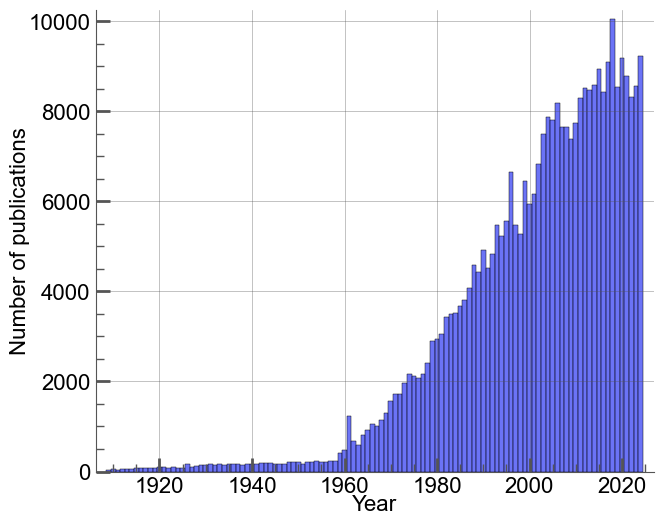

In [41]:
with aquarel.load_theme("scientific"):
    sns.set_palette("viridis")
    plt.figure(figsize=(7.2, 6))
    sns.histplot(data = works_pandas[:-10], x = "year", discrete=True, color = "#3944f3")
    plt.xlabel("Year", fontsize = 16)
    plt.xticks(fontsize=16)
    plt.ylabel("Number of publications", fontsize=16)
    plt.yticks(fontsize=16)
    plt.show()


#### N citations | Years

<Figure size 640x480 with 0 Axes>

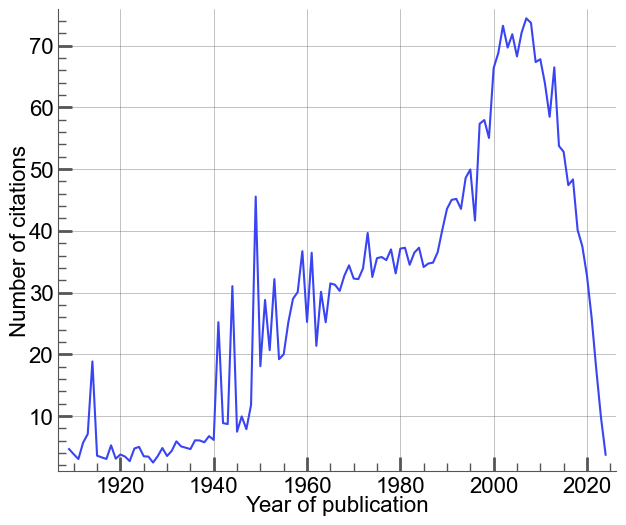

Mean citations count: 29.329887583995813
Median citations count: 31.370949074074076


In [43]:
with aquarel.load_theme("scientific"):
    plt.figure(figsize=(7.2, 6))
    sns.lineplot(data = group_year_mean, x = "year", y = "cited_by_count", color = "#3944f3")
    plt.xlabel("Year of publication", fontsize=16)
    plt.ylabel("Number of citations", fontsize=16)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.show()

mean_value = group_year_mean["cited_by_count"].mean()
median_value = group_year_mean["cited_by_count"].median()
print(f"Mean citations count: {mean_value}")
print(f"Median citations count: {median_value}")

#### N countries | years

In [ ]:
works

,title,year,cited_by_count,countries_distinct_count,institutions_distinct_count,citation_normalized_percentile,primary_topic,keywords,concepts,referenced_works_count,referenced_works,abstract,abstract_inverted_index,author_1,author_2,author_3,institution_1,country_1,cited_by_count_2025,cited_by_count_2024,cited_by_count_2023,cited_by_count_2022,cited_by_count_2021,cited_by_count_2020,cited_by_count_2019,cited_by_count_2018,cited_by_count_2017,cited_by_count_2016,cited_by_count_2015,cited_by_count_2014,cited_by_count_2013,cited_by_count_2012,primary_subfield,primary_field,primary_domain,keyword_1,…,country_162,country_163,country_164,country_165,keyword_13,country_166,country_167,country_168,country_169,country_170,country_171,country_172,country_173,country_174,country_175,country_176,country_177,country_178,country_179,country_180,country_181,country_182,country_183,country_184,country_185,country_186,country_187,country_188,country_189,country_190,country_191,country_192,age,mncs,authors_count,review,meta_analysis
i64,str,i64,i64,i64,i64,str,str,str,str,i64,str,str,str,str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,…,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,f64,i8,bool,bool
0,"""nitric oxide: physiology, path…",1991,15648,1,1,"""{'value': 0.997271, 'is_in_top…","""('Nitric Oxide and Endothelin …","""[{'id': 'https://openalex.org/…","""[{'id': 'https://openalex.org/…",0,"""[]""","""""",null,"""https://openalex.org/A50053578…","""https://openalex.org/A50561992…","""https://openalex.org/A50034300…","""['Wellcome Trust', 'https://op…","""GB""",32.0,54.0,114.0,112.0,129.0,168.0,180.0,208.0,242.0,278.0,319.0,403.0,400.0,485.0,"""('Physiology',)""","""('Medicine',)""","""('Health Sciences',)""","""Pathophysiology""",…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,34,347.571069,3,false,false
1,"""international union of pharmac…",2003,7170,4,9,"""{'value': 0.69256, 'is_in_top_…","""('Nicotinic Acetylcholine Rece…","""[{'id': 'https://openalex.org/…","""[{'id': 'https://openalex.org/…",3,"""['https://openalex.org/W200713…","""this issue of pharmacological …","""{'This': [0], 'issue': [1], 'o…","""https://openalex.org/A50789417…","""https://openalex.org/A50435673…","""https://openalex.org/A50377188…","""['National Institute on Aging'…","""DE""",null,1.0,null,null,20.0,14.0,22.0,14.0,19.0,30.0,296.0,571.0,685.0,724.0,"""('Molecular Biology',)""","""('Biochemistry, Genetics and M…","""('Life Sciences',)""","""Clinical Pharmacology""",…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,22,102.888138,8,true,false
2,"""theoretical basis, experimenta…",2006,4825,1,1,"""{'value': 0.992754, 'is_in_top…","""('Free Radicals and Antioxidan…","""[{'id': 'https://openalex.org/…","""[{'id': 'https://openalex.org/…",397,"""['https://openalex.org/W112108…","""the median-effect equation der…","""{'The': [0, 223, 248], 'median…","""https://openalex.org/A50262251…",null,null,"""['Memorial Sloan Kettering Can…","""US""",132.0,313.0,396.0,382.0,444.0,418.0,418.0,354.0,352.0,312.0,285.0,258.0,182.0,161.0,"""('Organic Chemistry',)""","""('Chemistry',)""","""('Physical Sciences',)""","""Plot (graphics)""",…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,19,66.895721,1,true,false
3,"""the effects of plant flavonoid…",2000,4728,1,1,"""{'value': 0.984496, 'is_in_top…","""('Phytochemicals and Antioxida…","""[{'id': 'https://openalex.org/…","""[{'id': 'https://openalex.org/…",1022,"""['https://openalex.org/W102315…","""flavonoids are nearly ubiquito…","""{'Flavonoids': [0, 57], 'are':…","""https://op

<Figure size 640x480 with 0 Axes>

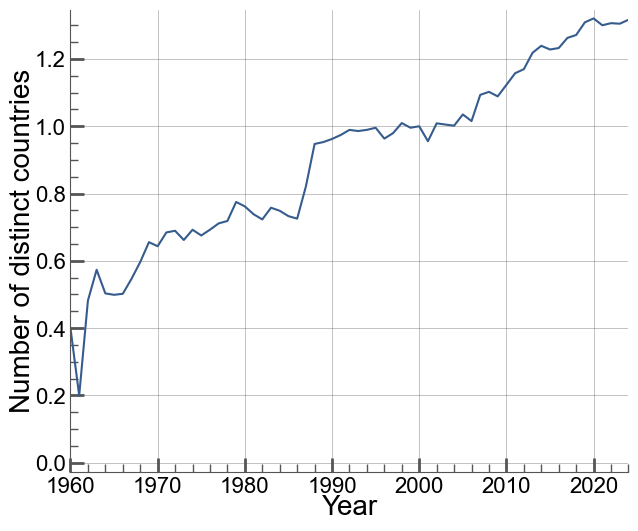

In [37]:
with aquarel.load_theme("scientific"):
    plt.figure(figsize=(7.2, 6))
    sns.lineplot(data = group_year_mean, x = "year", y = "countries_distinct_count", color = sns.color_palette("viridis")[1])
    plt.xlim(1960, 2024)
    plt.xlabel("Year", fontsize=20)
    plt.ylabel("Number of distinct countries", fontsize=20)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.show()

#### N institutions | years

<Figure size 640x480 with 0 Axes>

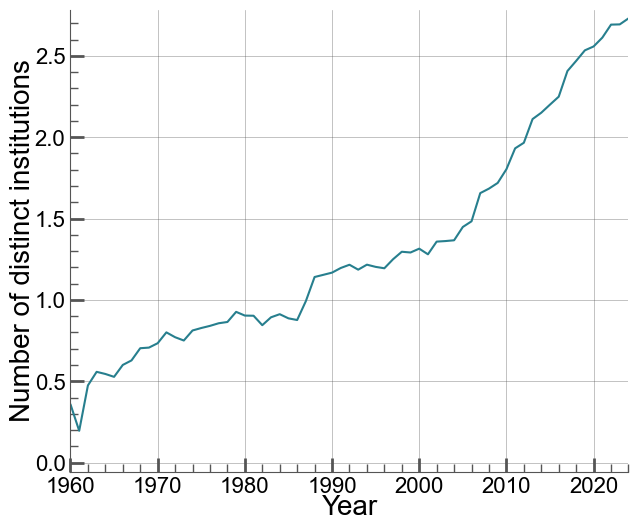

In [39]:
with aquarel.load_theme("scientific"):
    plt.figure(figsize=(7.2, 6))
    sns.lineplot(data = group_year_mean, x = "year", y = "institutions_distinct_count", color = sns.color_palette("viridis")[2])
    plt.xlim(1960, 2024)
    plt.xlabel("Year", fontsize=20)
    plt.ylabel("Number of distinct institutions", fontsize=20)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.show()

#### N references | Years

<Figure size 640x480 with 0 Axes>

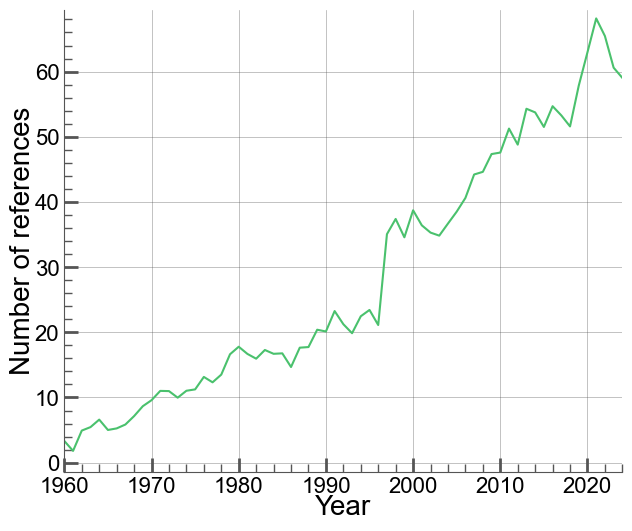

In [40]:
with aquarel.load_theme("scientific"):
    plt.figure(figsize=(7.2, 6))
    sns.lineplot(data = group_year_mean, x = "year", y = "referenced_works_count", color = sns.color_palette("viridis")[4])
    plt.xlim(1960, 2024)
    plt.xlabel("Year", fontsize=20)
    plt.ylabel("Number of references", fontsize=20)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.show()


In [ ]:
works[["cited_by_count", "referenced_works_count"]].groupby(by = "referenced_works_count").count()

,cited_by_count
referenced_works_count,
0,2573
1,115
2,70
3,55
4,90
...,...
740,1
773,1
890,1


#### N works | N citations

In [42]:
unknown_studies = works_pandas[works_pandas["cited_by_count"] == 0]
unknown_studies.shape[0]/works_pandas.shape[0]

0.13322850554254395

<Figure size 640x480 with 0 Axes>

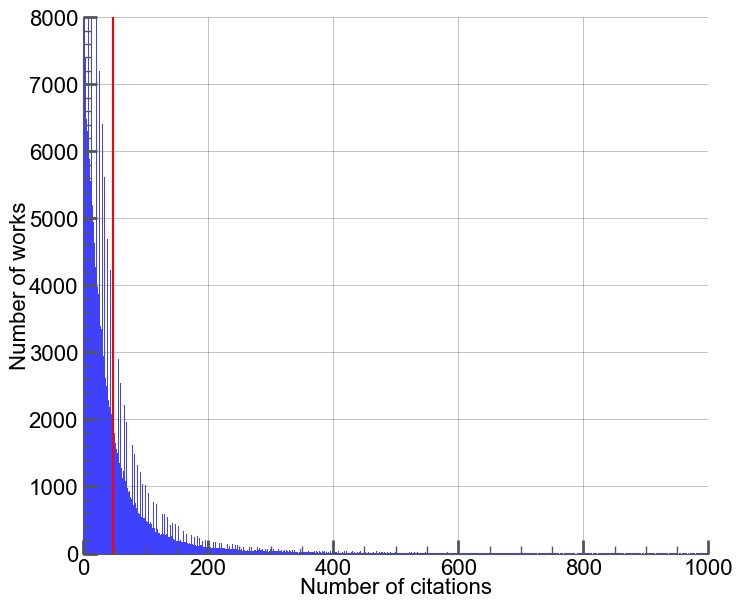

In [51]:
with aquarel.load_theme("scientific"):
    sns.displot(data = works_pandas, x = "cited_by_count", color="blue", legend = False, height = 6, aspect = 1.2)
    plt.xlim(0, 1000)
    plt.ylim(0, 8000)
    plt.axvline(x = works_pandas["cited_by_count"].mean(), color = "red")
    plt.xlabel("Number of citations", fontsize=16)
    plt.ylabel("Number of works", fontsize=16)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.show()

##### MNCS

In [ ]:
with aquarel.load_theme("scientific"):
    sns.displot(data = works, x = "mncs", legend = False, height = 6, aspect = 1.2)
    plt.xlim(0, 50)
    plt.xlabel("MNCS")
    plt.show()

<Figure size 640x480 with 0 Axes>

KeyboardInterrupt: 

#### N works | N references

<Figure size 640x480 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

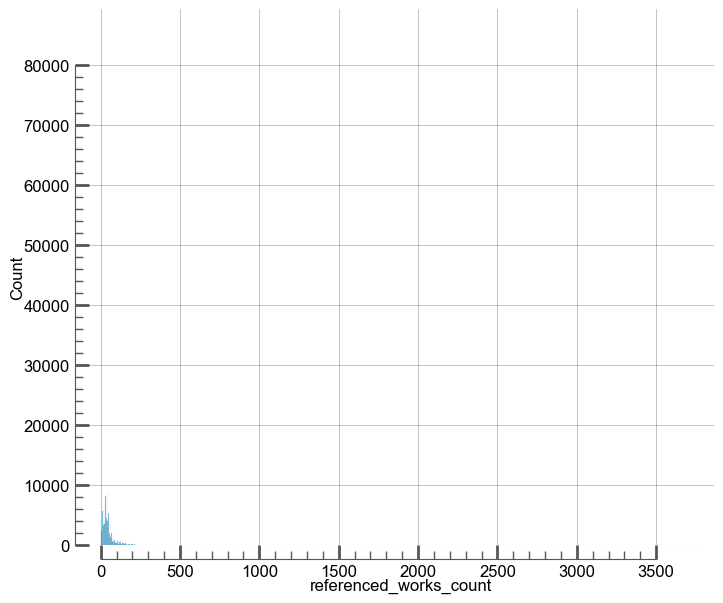

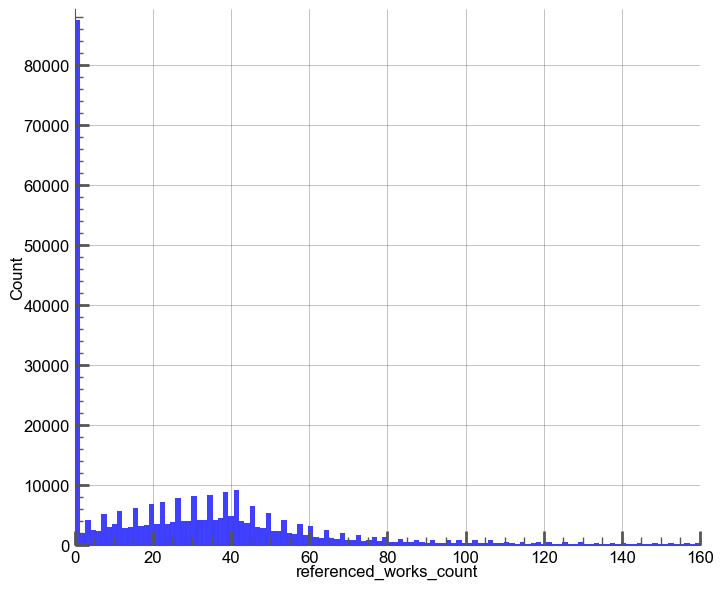

In [54]:
with aquarel.load_theme("scientific"):
    sns.displot(data = works_pandas, x = "referenced_works_count", color="blue", height = 6, aspect = 1.2)
    plt.xlim(0, 160)
    plt.show()


#### N citations | N references 

<Figure size 640x480 with 0 Axes>

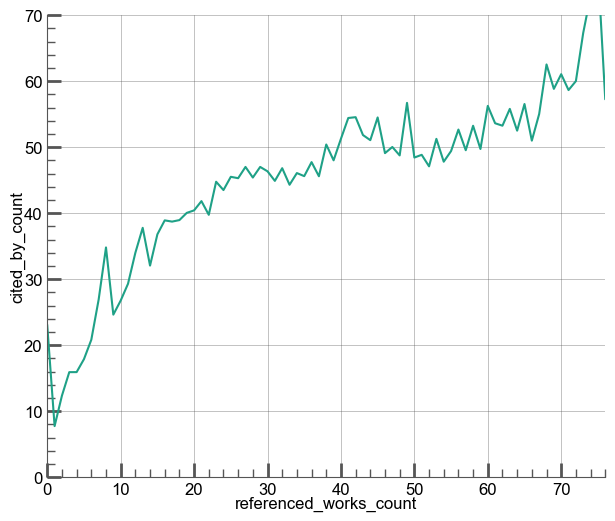

Mean authors count: 37.89223683063297
Median authors count: 27.0


In [55]:
with aquarel.load_theme("scientific"):
    plt.figure(figsize=(7.2, 6))
    sns.lineplot(data = group_references_mean, x = "referenced_works_count", y = "cited_by_count", color = sns.color_palette("viridis")[3])
    plt.xlim(0, 76)
    plt.ylim(0, 70)
    plt.show()

mean_value = works["referenced_works_count"].mean()
print(f"Mean authors count: {mean_value}")
median_value = works["referenced_works_count"].median()
print(f"Median authors count: {median_value}")

#### MNCS

<Figure size 640x480 with 0 Axes>

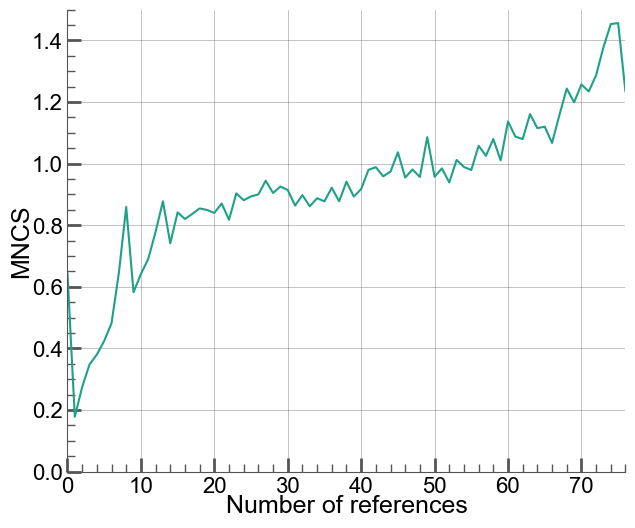

In [56]:
with aquarel.load_theme("scientific"):
    plt.figure(figsize=(7.2, 6))
    sns.lineplot(data = group_references_mean, x = "referenced_works_count", y = "mncs", color = sns.color_palette("viridis")[3])
    plt.xlim(0, 76)
    plt.ylim(0,1.5)
    plt.xlabel("Number of references", fontsize=18)
    plt.ylabel("MNCS", fontsize=18)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.show()

#### Kolmogorov-Smirnov | Citations and Pareto

In [58]:
xmin = 0
works_pandas_pareto = works_pandas["cited_by_count"][works_pandas["cited_by_count"] > xmin] # train only with the data after xmin

In [59]:
b, loc, scale = st.pareto.fit(works_pandas_pareto, floc = 0) # floc = fixed loc 


In [61]:
pareto_fitted = st.pareto(b, loc, scale)
D, p = st.kstest(works_pandas_pareto, pareto_fitted.cdf)
print(p)

0.0


c:\Users\gabri\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


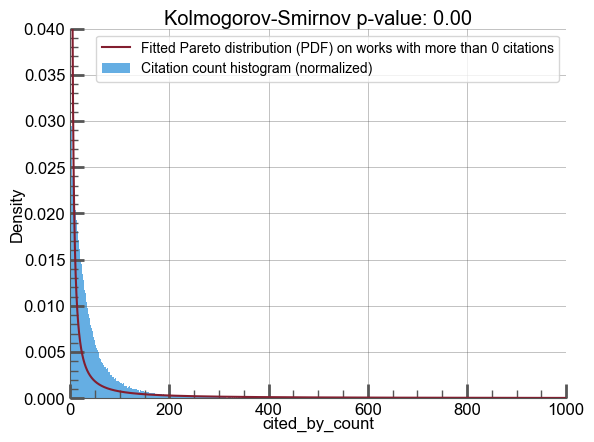

In [63]:
x = np.linspace(1, 1000, 10_000)
sns.lineplot(x = x, y = pareto_fitted.pdf(x), color = "#831e2f", label = f"Fitted Pareto distribution (PDF) on works with more than {xmin} citations")
sns.histplot(x = works_pandas_pareto, stat = "density", color = "#3293da", binwidth=1, label = "Citation count histogram (normalized)")
plt.xlim(0, 1000)
plt.ylim(0, 0.04)
plt.title(f"Kolmogorov-Smirnov p-value: {p:.2f}")
plt.legend()
plt.show()

In [316]:
works.shape

(26116, 394)

#### Gini coefficient for citations share

In [34]:
gini(works["cited_by_count"].values) #.values convert a Series in array

np.float64(0.6026971168973548)

<Figure size 640x480 with 0 Axes>

<Figure size 740x680 with 0 Axes>

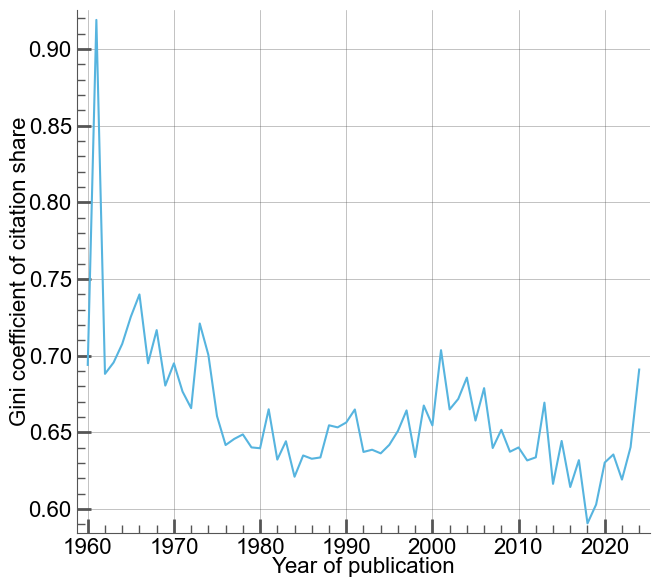

In [68]:
with aquarel.load_theme("scientific"):
    plt.figure(figsize=(7.4, 6.8))
    sns.lineplot(x = range(year_begin, year_end + 1), y = ginis)
    plt.xlabel("Year of publication", fontsize=16)
    plt.ylabel("Gini coefficient of citation share", fontsize=16)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.show()

#### Meta-analysis and Reviews

In [69]:
works["referenced_works_count"].mean()

37.89223683063297

In [72]:
works_pandas[works_pandas["review"] == True]["referenced_works_count"].mean()

np.float64(95.79607557383022)

## Authors 🧑‍🎓

### Data preparation ⚒️

#### Groups (group_[columns]_[operation])

In [15]:
group_Nauthors_mean = (
    works.select(["authors_count", "cited_by_count", "mncs"])
    .group_by(
        by="authors_count",
        maintain_order=True
    )
    .mean()
)

In [16]:
group_Nauthors_mean 

by,authors_count,cited_by_count,mncs
i8,f64,f64,f64
3,3.0,56.359239,1.169565
8,8.0,45.425301,0.959406
1,1.0,42.371138,0.903353
5,5.0,50.936552,1.066162
10,10.0,47.227493,1.01513
…,…,…,…
54,54.0,97.5,2.595988
80,80.0,39.0,0.806891
83,83.0,30.0,0.747479


#### List of authors

authors: each row is a collaboration, with the name of the author, the index of the work, the number of citations of the work

authors_summary: number of contributions for each author

In [33]:
works

,title,year,cited_by_count,countries_distinct_count,institutions_distinct_count,citation_normalized_percentile,primary_topic,keywords,concepts,referenced_works_count,referenced_works,abstract,abstract_inverted_index,author_1,author_2,author_3,institution_1,country_1,cited_by_count_2025,cited_by_count_2024,cited_by_count_2023,cited_by_count_2022,cited_by_count_2021,cited_by_count_2020,cited_by_count_2019,cited_by_count_2018,cited_by_count_2017,cited_by_count_2016,cited_by_count_2015,cited_by_count_2014,cited_by_count_2013,cited_by_count_2012,primary_subfield,primary_field,primary_domain,keyword_1,…,country_162,country_163,country_164,country_165,keyword_13,country_166,country_167,country_168,country_169,country_170,country_171,country_172,country_173,country_174,country_175,country_176,country_177,country_178,country_179,country_180,country_181,country_182,country_183,country_184,country_185,country_186,country_187,country_188,country_189,country_190,country_191,country_192,age,mncs,authors_count,review,meta_analysis
i64,str,i64,i64,i64,i64,str,str,str,str,i64,str,str,str,str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,…,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,f64,i8,bool,bool
0,"""nitric oxide: physiology, path…",1991,15648,1,1,"""{'value': 0.997271, 'is_in_top…","""('Nitric Oxide and Endothelin …","""[{'id': 'https://openalex.org/…","""[{'id': 'https://openalex.org/…",0,"""[]""","""""",null,"""https://openalex.org/A50053578…","""https://openalex.org/A50561992…","""https://openalex.org/A50034300…","""['Wellcome Trust', 'https://op…","""GB""",32.0,54.0,114.0,112.0,129.0,168.0,180.0,208.0,242.0,278.0,319.0,403.0,400.0,485.0,"""('Physiology',)""","""('Medicine',)""","""('Health Sciences',)""","""Pathophysiology""",…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,34,347.571069,3,false,false
1,"""international union of pharmac…",2003,7170,4,9,"""{'value': 0.69256, 'is_in_top_…","""('Nicotinic Acetylcholine Rece…","""[{'id': 'https://openalex.org/…","""[{'id': 'https://openalex.org/…",3,"""['https://openalex.org/W200713…","""this issue of pharmacological …","""{'This': [0], 'issue': [1], 'o…","""https://openalex.org/A50789417…","""https://openalex.org/A50435673…","""https://openalex.org/A50377188…","""['National Institute on Aging'…","""DE""",null,1.0,null,null,20.0,14.0,22.0,14.0,19.0,30.0,296.0,571.0,685.0,724.0,"""('Molecular Biology',)""","""('Biochemistry, Genetics and M…","""('Life Sciences',)""","""Clinical Pharmacology""",…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,22,102.888138,8,true,false
2,"""theoretical basis, experimenta…",2006,4825,1,1,"""{'value': 0.992754, 'is_in_top…","""('Free Radicals and Antioxidan…","""[{'id': 'https://openalex.org/…","""[{'id': 'https://openalex.org/…",397,"""['https://openalex.org/W112108…","""the median-effect equation der…","""{'The': [0, 223, 248], 'median…","""https://openalex.org/A50262251…",null,null,"""['Memorial Sloan Kettering Can…","""US""",132.0,313.0,396.0,382.0,444.0,418.0,418.0,354.0,352.0,312.0,285.0,258.0,182.0,161.0,"""('Organic Chemistry',)""","""('Chemistry',)""","""('Physical Sciences',)""","""Plot (graphics)""",…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,19,66.895721,1,true,false
3,"""the effects of plant flavonoid…",2000,4728,1,1,"""{'value': 0.984496, 'is_in_top…","""('Phytochemicals and Antioxida…","""[{'id': 'https://openalex.org/…","""[{'id': 'https://openalex.org/…",1022,"""['https://openalex.org/W102315…","""flavonoids are nearly ubiquito…","""{'Flavonoids': [0, 57], 'are':…","""https://op

In [17]:
authors = (
    works
    .sort(by="year") 
    .with_row_index("index_work") # add an index columns that correspond to the order of publication
    .unpivot(
        on=cols_authors,
        index=["title", "year", "index_work", "cited_by_count", "mncs"],
        variable_name="author_pos",
        value_name="author_name"
    )
    .filter(
        pl.col("author_name").is_not_null()
    )
    .with_columns(
        count = pl.lit(1)
    )
)


In [18]:
authors.drop("title")

year,index_work,cited_by_count,mncs,author_pos,author_name,count
i64,u32,i64,f64,str,str,i32
1909,0,47,10.143885,"""author_1""","""https://openalex.org/A51102708…",1
1909,1,15,3.23741,"""author_1""","""https://openalex.org/A51116416…",1
1909,2,14,3.021583,"""author_1""","""https://openalex.org/A50125106…",1
1909,3,12,2.589928,"""author_1""","""https://openalex.org/A51121624…",1
1909,4,11,2.374101,"""author_1""","""https://openalex.org/A51136090…",1
…,…,…,…,…,…,…
2022,312194,16,0.912864,"""author_100""","""https://openalex.org/A50240028…",1
2022,314002,15,0.85581,"""author_100""","""https://openalex.org/A50900590…",1
2022,314039,3,0.171162,"""author_100""","""https://openalex.org/A51081304…",1


In [34]:
top_authors = (
    authors
    .drop(["title"])
    .group_by(by = "author_name")
    .sum()
    .sort(by = "cited_by_count", descending=True)
    .drop(["index_work", "author_name"])
)


In [35]:
top_authors.filter(pl.col("by")=="https://openalex.org/A5056315342")


by,year,cited_by_count,mncs,author_pos,count
str,i64,i64,f64,str,i32
"""https://openalex.org/A50563153…",8032,2455,33.964755,null,4


In [36]:
top_10_authors

by,year,cited_by_count,mncs,count,name
str,i64,i64,f64,i32,str
"""https://openalex.org/A50202294…",56386,48462,733.728501,28,"""Abderrahim Nemmar"""
"""https://openalex.org/A50818977…",38056,48231,728.547586,19,"""Haider Raza"""
"""https://openalex.org/A50843467…",20119,47851,720.352289,10,"""Annie John"""
"""https://openalex.org/A50406885…",16069,35703,555.78343,8,"""Christopher A. Lipinski"""
"""https://openalex.org/A50053578…",179207,34088,779.177671,90,"""Salvador Moncada"""
"""https://openalex.org/A50486756…",134631,31433,544.984336,67,"""Bharat B. Aggarwal"""
"""https://openalex.org/A50727789…",24136,30698,487.790938,12,"""Franco Lombardo"""
"""https://openalex.org/A50508376…",6010,29859,470.544288,3,"""Beryl W. Dominy"""
"""https://openalex.org/A50357810…",6010,29859,470.544288,3,"""Paul J. Feeney"""


In [37]:
top_10_authors = top_authors.head(n = 10)

top_10_authors = (
    top_10_authors
    .with_columns(
        name = pl.col("by").map_elements(lambda x: (alex.Authors()[x]["display_name"])),
        institution = pl.col("by").map_elements(lambda x: (alex.Authors()[x]["affiliations"][0]["institution"]["id"]))
    )
)


# for index, row in top_10_authors.iterrows():
#     top_10_authors.loc[index, "name"] = 

# top_10_authors.columns = ["author", "number of citations", "number of contributions", "name"]

<sys>:0: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
<sys>:0: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.


In [39]:
top_10_authors = (
    top_10_authors
    .with_columns(
        country = pl.col("institution").map_elements(lambda x: (alex.Institutions()[x]["country_code"])),
    )
)

C:\Users\gabri\AppData\Local\Temp\ipykernel_33492\3383130727.py:3: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
  .with_columns(


In [40]:
top_10_authors

by,year,cited_by_count,mncs,author_pos,count,name,institution,country
str,i64,i64,f64,str,i32,str,str,str
"""https://openalex.org/A50202294…",56386,48462,733.728501,null,28,"""Abderrahim Nemmar""","""https://openalex.org/I20172641…","""AE"""
"""https://openalex.org/A50818977…",38056,48231,728.547586,null,19,"""Haider Raza""","""https://openalex.org/I58956616""","""US"""
"""https://openalex.org/A50843467…",20119,47851,720.352289,null,10,"""Annie John""","""https://openalex.org/I20172641…","""AE"""
"""https://openalex.org/A50406885…",16069,35703,555.78343,null,8,"""Christopher A. Lipinski""","""https://openalex.org/I42101472…","""US"""
"""https://openalex.org/A50053578…",179207,34088,779.177671,null,90,"""Salvador Moncada""","""https://openalex.org/I63634437""","""ES"""
"""https://openalex.org/A50486756…",134631,31433,544.984336,null,67,"""Bharat B. Aggarwal""","""https://openalex.org/I28024647…","""IN"""
"""https://openalex.org/A50727789…",24136,30698,487.790938,null,12,"""Franco Lombardo""","""https://openalex.org/I47834966""","""US"""
"""https://openalex.org/A50357810…",6010,29859,470.544288,null,3,"""Paul J. Feeney""","""https://openalex.org/I18085789…","""US"""
"""https://openalex.org/A50508376…",6010,29859,470.544288,null,3,"""Beryl W. Dominy""","""https://openalex.org/I18085789…","""US"""


#### Impact of the past contributions

In [46]:
authors = authors.sort("index_work").with_columns([
    (pl.col("count").cum_sum().over("author_name") - pl.col("count")).alias("cumulative_count"),  # over() = operation group by group, like group_by+agg
    (pl.col("cited_by_count").cum_sum().over("author_name") - pl.col("cited_by_count")).alias("cumulative_citations"),
    (pl.col("mncs").cum_sum().over("author_name") - pl.col("mncs")).alias("cumulative_mncs")
])

authors = authors.with_columns(
    pl.when(pl.col("cumulative_count") == 0)
    .then(pl.lit(1))
    .otherwise(pl.col("cumulative_mncs") / pl.col("cumulative_count"))
    .alias("mean_past_mncs_authors")
)

In [47]:
test = authors.filter(pl.col("author_name") == "https://openalex.org/A5080551159")
test

title,year,index_work,cited_by_count,mncs,author_pos,author_name,count,cumulative_count,cumulative_citations,cumulative_mncs,mean_past_mncs_authors
str,i64,u32,i64,f64,str,str,i32,i32,i64,f64,f64
"""quantitative studies on the ga…",1910,44,1,0.263441,"""author_1""","""https://openalex.org/A50805511…",1,0,0,0.0,1.0
"""the actions of caffein on the …",1911,80,21,6.943548,"""author_1""","""https://openalex.org/A50805511…",1,1,1,0.263441,0.263441
"""the actions of caffein on the …",1911,113,0,0.0,"""author_1""","""https://openalex.org/A50805511…",1,2,22,7.206989,3.603495
"""alcohol and caffein: a study o…",1912,127,11,1.941176,"""author_2""","""https://openalex.org/A50805511…",1,3,22,7.206989,2.40233
"""quantitative studies of vagus …",1914,236,3,0.159242,"""author_2""","""https://openalex.org/A50805511…",1,4,33,9.148166,2.287041
…,…,…,…,…,…,…,…,…,…,…,…
"""the pharmacology of trimethyl …",1939,3158,18,2.671493,"""author_1""","""https://openalex.org/A50805511…",1,69,309,74.016757,1.072707
"""pharmacologic responses of dap…",1941,3508,8,0.317618,"""author_1""","""https://openalex.org/A50805511…",1,70,327,76.68825,1.095546
"""intravenous injections of solu…",1942,3694,10,1.130807,"""author_1""","""https://openalex.org/A50805511…",1,71,335,77.005868,1.08459


In [48]:
works = (
    works
    .sort(by="year") 
    .with_row_index("index_work")
    .with_columns(
    mean_past_contributions_authors = pl.col("index_work").map_elements(lambda x: authors.filter(pl.col("index_work") == x).select("cumulative_count").mean().item()),
    mean_past_mncs_authors = pl.col("index_work").map_elements(lambda x: authors.filter(pl.col("index_work") == x).select("mean_past_mncs_authors").mean().item()) 
    )
    .with_columns(
        mean_past_mncs_authors = pl.col("mean_past_mncs_authors").fill_null(1),
        mean_past_contributions_authors = pl.col("mean_past_contributions_authors").fill_null(0)
    )
)

<sys>:0: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
<sys>:0: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.


In [53]:
works["mean_past_contributions_authors"].is_null().sum()

0

In [54]:
works["mean_past_mncs_authors"].is_null().sum()

0

In [55]:
(works["mean_past_contributions_authors"] == float("nan")).sum()

0

In [56]:
(works["mean_past_contributions_authors"] == 0.).sum()

66388

### Data Analysis 📊

#### N authors | Years

In [28]:
group_year_mean.sort_values(by = "year", inplace=True, ascending=False)
group_year_mean.head()

NameError: name 'group_year_mean' is not defined

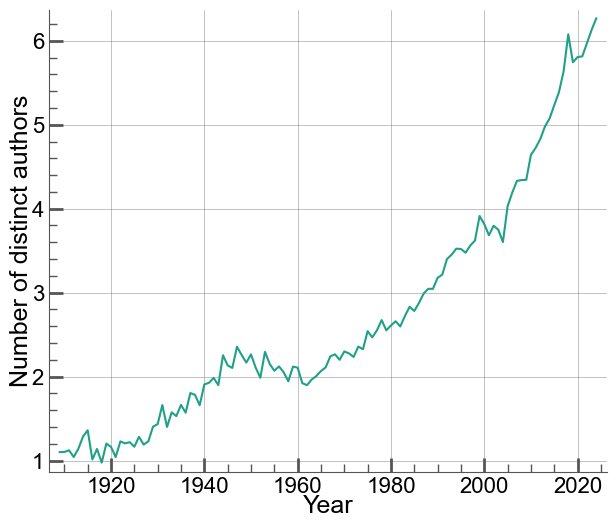

Mean authors count: 2.6985026258827105
Median authors count: 2.260023262178435


In [27]:
with aquarel.load_theme("scientific"):
    plt.figure(figsize=(7.2, 6))
    sns.lineplot(data = group_year_mean, x = "year", y = "authors_count", color = sns.color_palette("viridis")[3])
    #plt.xlim(1980, 2024)
    plt.xlabel("Year", fontsize=18)
    plt.ylabel("Number of distinct authors", fontsize=18)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.show()

mean_value = group_year_mean["authors_count"].mean()
print(f"Mean authors count: {mean_value}")
median_value = group_year_mean["authors_count"].median()
print(f"Median authors count: {median_value}")

#### N citations | N authors

<Figure size 640x480 with 0 Axes>

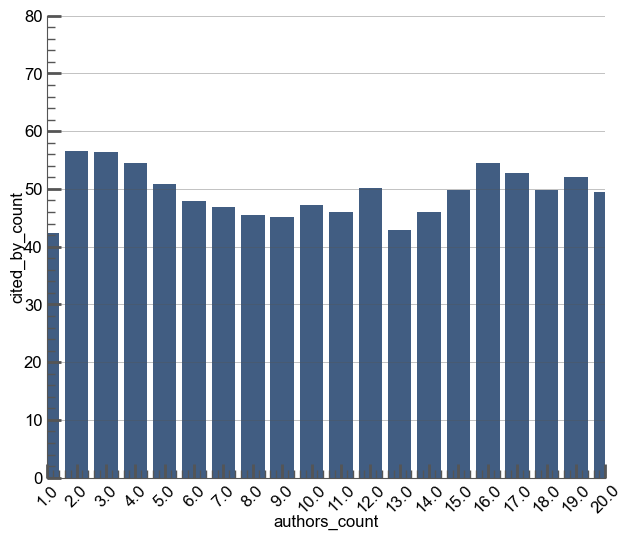

Mean authors count: 2.6985026258827105
Median authors count: 2.260023262178435


In [29]:
with aquarel.load_theme("scientific"):
    plt.figure(figsize=(7.2, 6))
    sns.barplot(data = group_Nauthors_mean, x = "authors_count", y = "cited_by_count", color = sns.color_palette("viridis")[1])
    plt.xlim(1,20)
    plt.ylim(0,80)
    plt.xticks(rotation = 45)
    plt.show()
    # Not enough articles beyond 20 authors

mean_value = group_year_mean["authors_count"].mean()
median_value = group_year_mean["authors_count"].median()
print(f"Mean authors count: {mean_value}")
print(f"Median authors count: {median_value}")

##### MNCS

<Figure size 640x480 with 0 Axes>

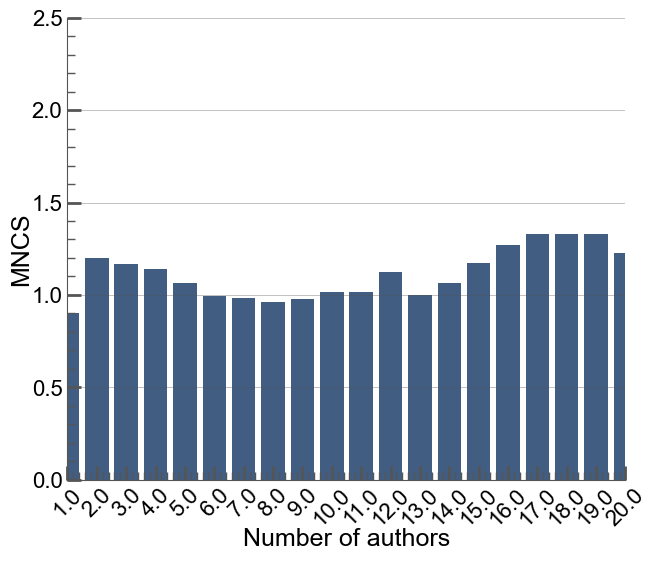

In [30]:
with aquarel.load_theme("scientific"):
    plt.figure(figsize=(7.2, 6))
    sns.barplot(data = group_Nauthors_mean, x = "authors_count", y = "mncs", color = sns.color_palette("viridis")[1])
    plt.xlim(1,20)
    plt.ylim(0,2.5)
    plt.xticks(rotation = 45)
    plt.xlabel("Number of authors", fontsize=18)
    plt.ylabel("MNCS", fontsize=18)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.show()
    # Not enough articles beyond 20 authors

#### Top authors

In [67]:
palette = ["#5aa37b","#45637d", "#cc6355", "#e0b474",]

<Figure size 640x480 with 0 Axes>

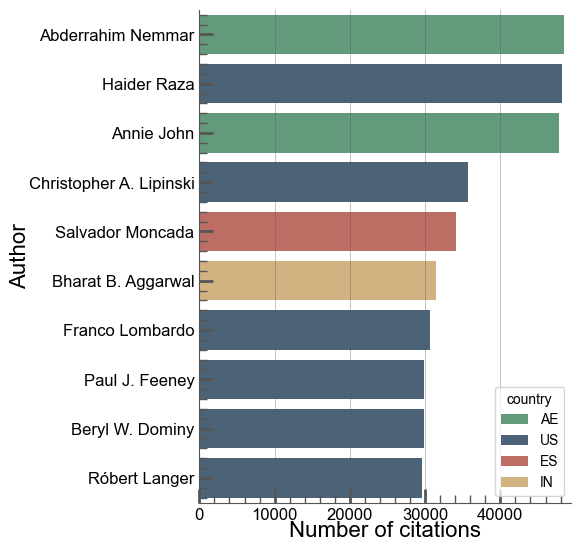

In [68]:
with aquarel.load_theme("scientific"):
    plt.figure(figsize=(4.8,6.4))
    sns.barplot(data = top_10_authors, x = "cited_by_count", y = "name", hue="country", legend=True, palette=palette, orient = "h")
    #plt.xticks(rotation = 90)
    plt.xlabel("Number of citations", fontsize=16)
    plt.ylabel("Author", fontsize=16)
    plt.show()

#### Impact of the past contributions

Percentage of contributions from authors without previous works in the journal : 

In [242]:
authors[authors["cumulative_count"] ==0].shape[0]/authors.shape[0]*100

56.24030108984536

## Countries 🗺️

### Data preparation ⚒️

#### List of countries

Countries = list of collaborations

In [ ]:
countries_col = [f"country_{i}" for i in range(1, 193)]

countries = (
    works
    .sort(by="year")
    .with_row_index("index_work")
    .unpivot(
        on=countries_col,
        index=[
            "year",
            "index_work", 
            "cited_by_count",
            "mncs",
        ],
        variable_name="country_pos",
        value_name="country_name"
    )
    .filter(
        pl.col("country_name").is_not_null()
    )
    .with_columns(
        count = pl.lit(1)
    )

)

DuplicateError: could not create a new DataFrame: column with name 'index_work' has more than one occurrence

#### Groups (group_[columns]_[operation])

In [58]:
group_countriesyears = (
    countries
    .drop("country_pos")
    .group_by(["country_name", "year"], maintain_order=True).sum()
    .sort("year")
)

NameError: name 'countries' is not defined

In [62]:
group_countries = (
    countries
    .with_columns(
        age=pl.lit(2025)-pl.col("year")
    )
    .drop(["country_pos", "year"])
    .group_by(
        by="country_name",
        maintain_order=True
    )
    .agg(
        count=pl.col("count").sum(),
        mean_mncs=pl.col("mncs").mean(),
        mean_cited_by_count=pl.col("cited_by_count").mean(),
        mean_age=pl.col("age").mean()
    )
    .sort("count", descending=True)
    .rename({"by":"country_name"})
)

NameError: name 'countries' is not defined

In [59]:
group_countriesyears = (
    group_countriesyears
    .with_columns(
        cum_cited_by_count=pl.col("cited_by_count").cum_sum().over("country_name"),
        cum_mncs=pl.col("mncs").cum_sum().over("country_name"),
        cum_count=pl.col("count").cum_sum().over("country_name")
    ) 
    .with_columns(
        mean_mncs=pl.col("mncs")/pl.col("count"),
        mean_cum_mncs=pl.col("cum_mncs")/pl.col("cum_count")
    )
)

NameError: name 'group_countriesyears' is not defined

In [60]:
group_Ncountries_mean = (
    works.select(["cited_by_count", "countries_distinct_count", "mncs"])
    .group_by("countries_distinct_count")
    .mean()
) 

In [61]:
top_countries = (
    group_countries
    .sort("count", descending=True)
    .head(5)
    .select("country_name")
    .to_series()
    .to_list()
)

NameError: name 'group_countries' is not defined

### Data analysis 📊

#### Average ages of publications per country

In [29]:
age_countries = (
    group_countries
    .sort("count", descending=True)
    .head(5)
)

C:\Users\gabri\AppData\Local\Temp\ipykernel_27080\3130310183.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = age_countries, x = "country_name", y = "mean_age", palette = "viridis_r")


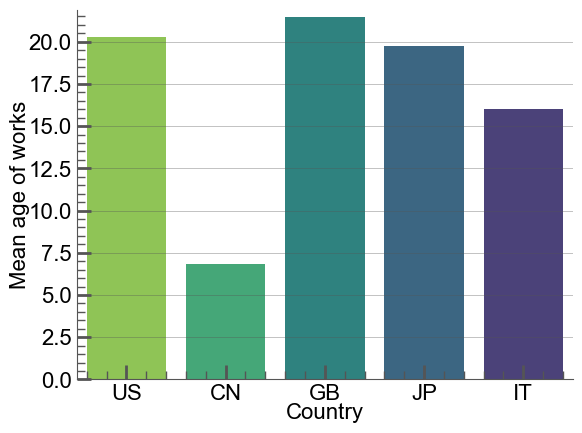

<Figure size 640x480 with 0 Axes>

In [30]:
with aquarel.load_theme("scientific"):
    sns.barplot(data = age_countries, x = "country_name", y = "mean_age", palette = "viridis_r")
    plt.ylabel("Mean age of works", fontsize=16)
    plt.xlabel("Country", fontsize=16)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.show()

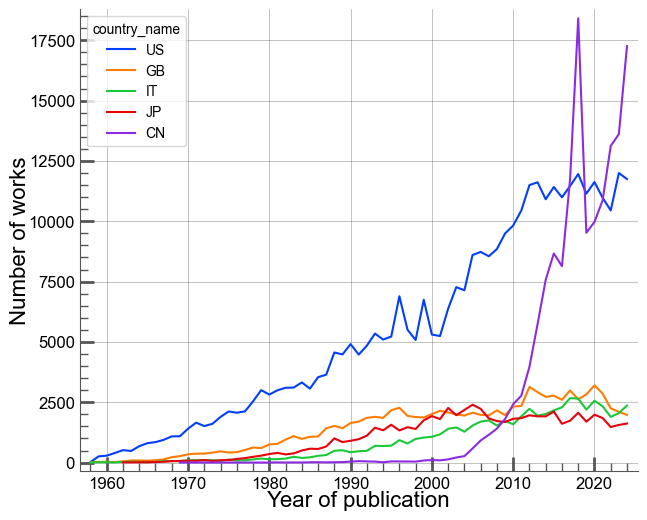

In [31]:
with aquarel.load_theme("scientific"):
    plt.figure(figsize=(7.2, 6))
    sns.lineplot(data = group_countriesyears.filter(pl.col("country_name").is_in(top_countries)), x = "year", y = "count", hue = "country_name", palette = "bright")
    #plt.xlim(1980, 2024)
    plt.xlabel("Year of publication", fontsize=16)
    plt.ylabel("Number of works", fontsize=16)
    plt.show()

#### Quadrant

In [32]:
group_countries_pandas = group_countries.to_pandas()

##### MNCS MinMaxScaling

<Figure size 640x480 with 0 Axes>

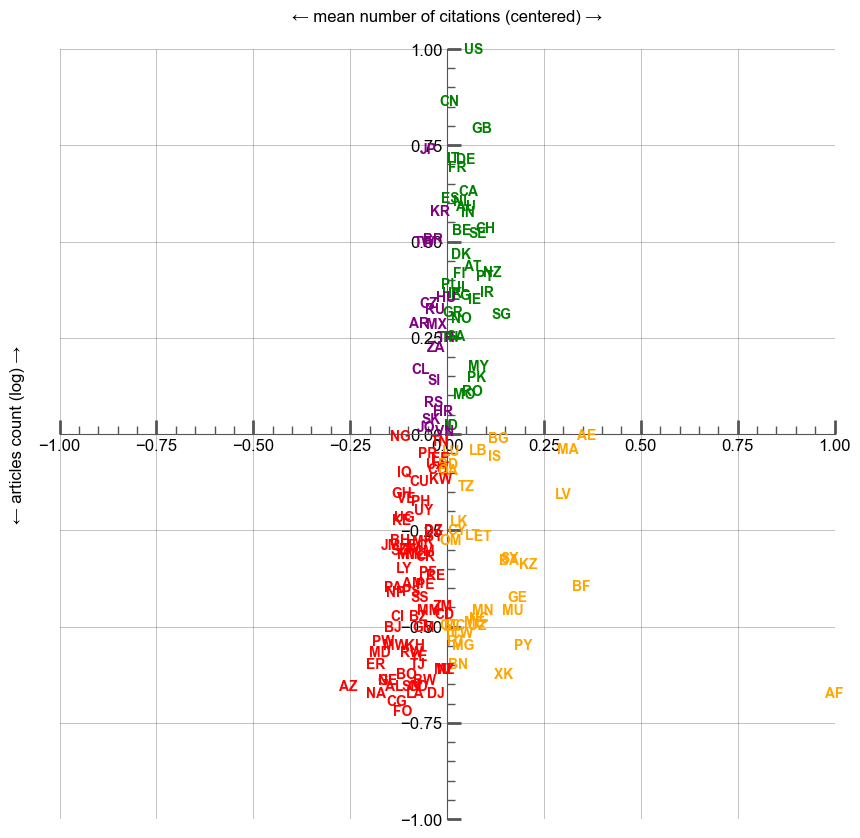

In [33]:
# studying only the countries with more than 5 articles published
group_countries_pandas = group_countries_pandas[group_countries_pandas["count"] > 5]
# log(x)
group_countries_pandas["count_log"] = np.log(group_countries_pandas["count"])
# centering y
group_countries_pandas["mean_mncs_centered"] = group_countries_pandas["mean_mncs"] - group_countries_pandas["mean_mncs"].mean()
# rescale [-1, 1]
group_countries_pandas["count_viz"] = -1 + 2 * group_countries_pandas["count_log"] / group_countries_pandas["count_log"].max()
group_countries_pandas["mean_mncs_viz"] = group_countries_pandas["mean_mncs_centered"] / group_countries_pandas["mean_mncs_centered"].max()

plt.figure(figsize = (10, 10))
for index, row in group_countries_pandas.iterrows():
    if row["mean_mncs_viz"] >= 0 and row["count_viz"] >= 0:
        color = "green"
    elif row["mean_mncs_viz"] < 0 and row["count_viz"] >= 0:
        color = "purple"
    elif row["mean_mncs_viz"] < 0 and row["count_viz"] < 0:
        color = "red"
    else:
        color = "orange"
    plt.text(row["mean_mncs_viz"], row["count_viz"], row["country_name"],
             ha = "center", va = "center", fontsize = 10, fontweight = "bold", color = color)
    

plt.xlabel("← mean number of citations (centered) →", labelpad = - 320) # labelpad = décalage du label
plt.ylabel("← articles count (log) →", labelpad = 270)
plt.xlim(-1, 1)
plt.ylim(-1, 1)
# position of the two axes
ax = plt.gca()
ax.spines['left'].set_position('zero')   # axe Y à x=0
ax.spines['bottom'].set_position('zero') # axe X à y=0

plt.show()

##### MNCS StandardScaling

<Figure size 640x480 with 0 Axes>

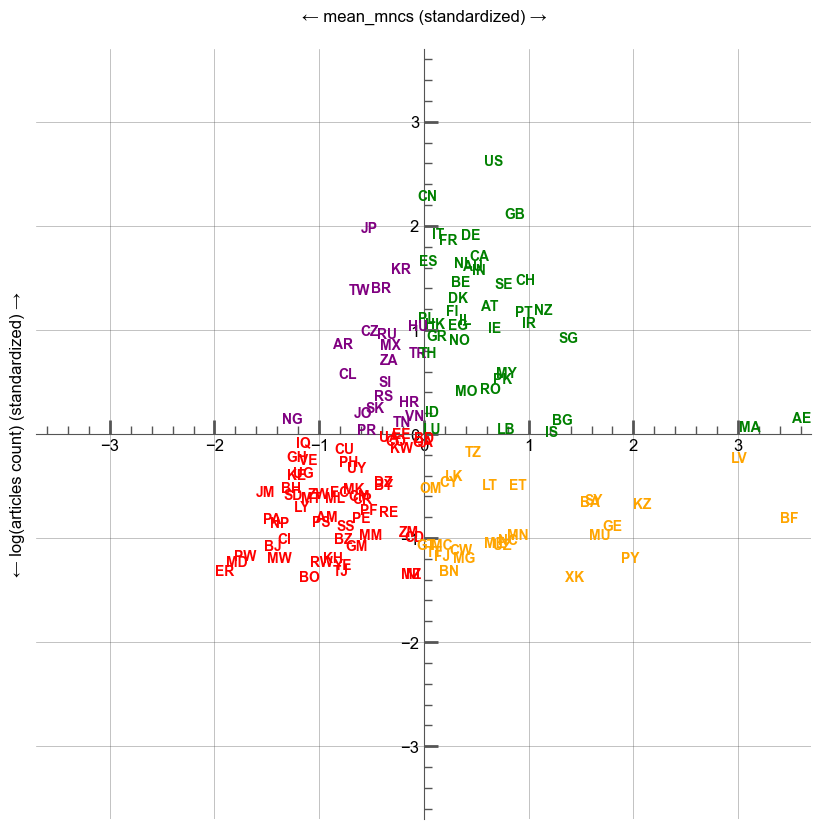

In [36]:
# studying only the countries with more than 5 articles published
group_countries_pandas = group_countries_pandas[group_countries_pandas["count"] > 10]
# log(x)
group_countries_pandas["count_log"] = np.log(group_countries_pandas["count"])
# standard scaling
group_countries_pandas["mean_mncs_viz"] = (group_countries_pandas["mean_mncs"] - group_countries_pandas["mean_mncs"].mean())/group_countries_pandas["mean_mncs"].std()
group_countries_pandas["count_viz"] = (group_countries_pandas["count_log"] - group_countries_pandas["count_log"].mean())/group_countries_pandas["count_log"].std()

plt.figure(figsize = (10, 10))
for index, row in group_countries_pandas.iterrows():
    if row["mean_mncs_viz"] >= 0 and row["count_viz"] >= 0:
        color = "green"
    elif row["mean_mncs_viz"] < 0 and row["count_viz"] >= 0:
        color = "purple"
    elif row["mean_mncs_viz"] < 0 and row["count_viz"] < 0:
        color = "red"
    else:
        color = "orange"
    if row["country_name"] != "SA":
        plt.text(row["mean_mncs_viz"], row["count_viz"], row["country_name"],
                 ha = "center", va = "center", fontsize = 10, fontweight = "bold", color = color)
    

plt.xlabel("← mean_mncs (standardized) →", labelpad = - 320) # labelpad = décalage du label
plt.ylabel("← log(articles count) (standardized) →", labelpad = 270)
plt.xlim(-3.7, 3.7)
plt.ylim(-3.7, 3.7)
# position of the two axes
ax = plt.gca()
ax.spines['left'].set_position('zero')   # axe Y à x=0
ax.spines['bottom'].set_position('zero') # axe X à y=0

plt.show()

#### N citations | N countries

##### MNCS

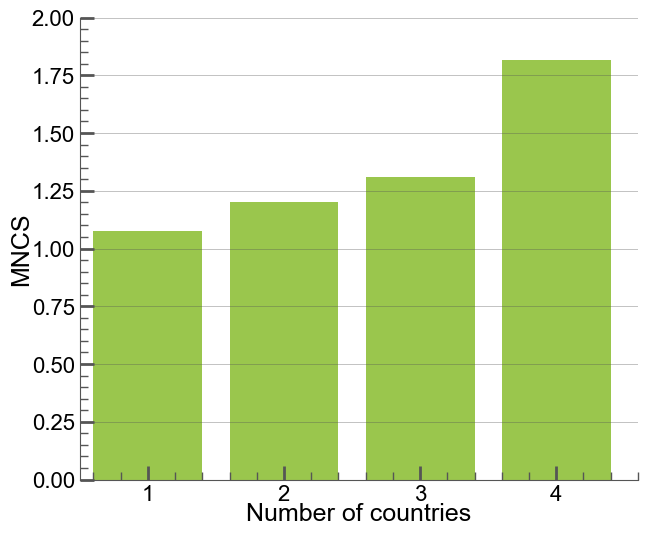

In [35]:
with aquarel.load_theme("scientific"):
    plt.figure(figsize=(7.2, 6))
    sns.barplot(data = group_Ncountries_mean, x = "countries_distinct_count", y = "mncs", color = sns.color_palette("viridis")[5])
    plt.xlim(0.5, 4.6)
    plt.ylim(0,2)
    # plt.xticks(rotation = 45)
    plt.xlabel("Number of countries", fontsize=18)
    plt.ylabel("MNCS", fontsize=18)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.show()

## Institutions 🏦

### Data Preparation ⚒️

NB: We are counting the contributions, not the articles

#### List of institutions

In [71]:
institutions_col = [f"institution_{i}" for i in range(1, 193)]

institutions = ( 
    works
    .sort(by="year")
    .with_row_index("index_work")
    .unpivot(
        on=institutions_col,
        index=[
            "year",
            "index_work", 
            "cited_by_count",
            "mncs",
        ],
        variable_name="institution_pos",
        value_name="institution_name"
    )
    .filter(
        pl.col("institution_name").is_not_null()
    )
    .with_columns(
        count = pl.lit(1),
        institution_simple = pl.col("institution_name").map_elements(lambda x: (x.split("',", 1)[0])[2:])
    )

)

<sys>:0: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.


#### Groups (group_[columns]_[operation])

In [72]:
group_institutionsyears = (
    institutions
    .drop("institution_pos")
    .group_by(["institution_simple", "year", "institution_name"]).sum()
    .sort("year")
)

In [73]:
group_institutions_sum = (
    institutions
    .select(["institution_simple", "count", "cited_by_count", "mncs", "institution_name"])
    .group_by(["institution_simple", "institution_name"]).sum()
).sort("cited_by_count", descending=True)




In [74]:
top_institutions = (
    group_institutions_sum
    .sort("count", descending=True)
    .head(5)
    .select("institution_simple")
    .to_series().to_list()
)

In [75]:
group_institutionsyears = (
    group_institutionsyears
    .with_columns(
        cum_cited_by_count=pl.col("cited_by_count").cum_sum().over("institution_name"),
        cum_mncs=pl.col("mncs").cum_sum().over("institution_name"),
        cum_count=pl.col("count").cum_sum().over("institution_name")
    )
    .with_columns(
        mean_mncs=pl.col("mncs")/pl.col("count"),
        mean_cum_mncs=pl.col("cum_mncs")/pl.col("cum_count")
    )
    .sort("count", descending=True)
)

In [76]:
# renaming the CNRS for a more lisible visualization
group_institutions_sum = group_institutions_sum.with_columns(
    pl.when(pl.col("institution_simple")=="Centre National de la Recherche Scientifique")
    .then(pl.lit("CNRS"))
    .otherwise(pl.col("institution_simple"))
    .alias("institution_simple")
)


In [77]:
group_Ninstitutions_mean = (
    works
    .select(["cited_by_count", "institutions_distinct_count", "mncs"])
    .group_by(by = "institutions_distinct_count")
    .mean()
)


#### Features in works for future modelling

In [74]:
institutions = institutions.sort("index_work").with_columns([
    (pl.col("count").cum_sum().over("institution_name") - pl.col("count")).alias("cumulative_count"),  # over() = operation group by group, like group_by+agg
    (pl.col("cited_by_count").cum_sum().over("institution_name") - pl.col("cited_by_count")).alias("cumulative_citations"),
    (pl.col("mncs").cum_sum().over("institution_name") - pl.col("mncs")).alias("cumulative_mncs")
])

institutions = institutions.with_columns(
    pl.when(pl.col("cumulative_count") == 0)
    .then(pl.lit(1))
    .otherwise(pl.col("cumulative_mncs") / pl.col("cumulative_count"))
    .alias("mean_past_mncs_institutions")
)
test = institutions.filter(pl.col("institution_name") == "https://openalex.org/A5080551159")
test
works = (
    works
    .sort(by="year") 
    #.with_row_index("index_work")
    .with_columns(
    mean_past_contributions_institutions = pl.col("index_work").map_elements(lambda x: institutions.filter(pl.col("index_work") == x).select("cumulative_count").mean().item()),
    mean_past_mncs_institutions = pl.col("index_work").map_elements(lambda x: institutions.filter(pl.col("index_work") == x).select("mean_past_mncs_institutions").mean().item()) 
    )
    .with_columns(
        mean_past_mncs_institutions = pl.col("mean_past_mncs_institutions").fill_null(1),
        mean_past_contributions_institutions = pl.col("mean_past_contributions_institutions").fill_null(0)
    )
)

<sys>:0: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
<sys>:0: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.


In [75]:
(works["mean_past_mncs_institutions"].is_null()).sum()

0

In [ ]:
works[works["institution_1"] == "['University of Cambridge', 'https://openalex.org/I241749']"]["institutions_mean_number_works"].plot()
works[works["institution_1"] == "['China Pharmaceutical University', 'https://openalex.org/I161716053']"]["institutions_mean_number_works"].plot()  

<Axes: >

### Data Analysis 📊

In [46]:
group_institutionsyears_pandas = group_institutionsyears.to_pandas()
group_institutions_sum_pandas = group_institutions_sum.to_pandas()

#### Top institutions evolution, and link with prestige

5,221 institutions.

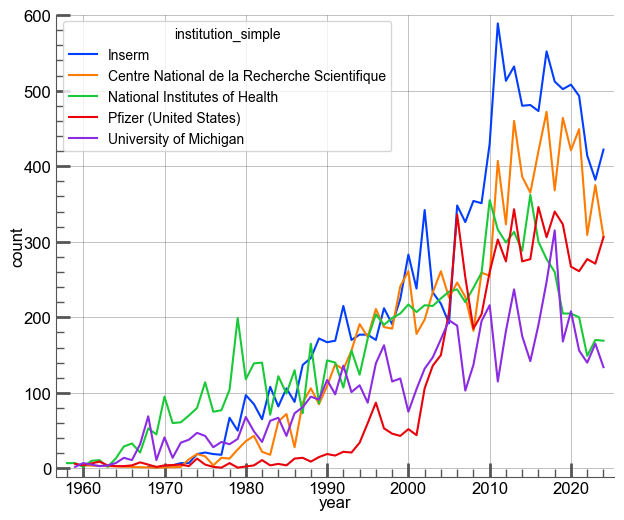

In [47]:
with aquarel.load_theme("scientific"):
    plt.figure(figsize=(7.2, 6))
    sns.lineplot(data = group_institutionsyears_pandas[group_institutionsyears_pandas["institution_simple"].isin(top_institutions)], x = "year", y = "count", hue = "institution_simple", palette = "bright")
    plt.show()

#### Citations distribution and Pareto law

<Figure size 640x480 with 0 Axes>

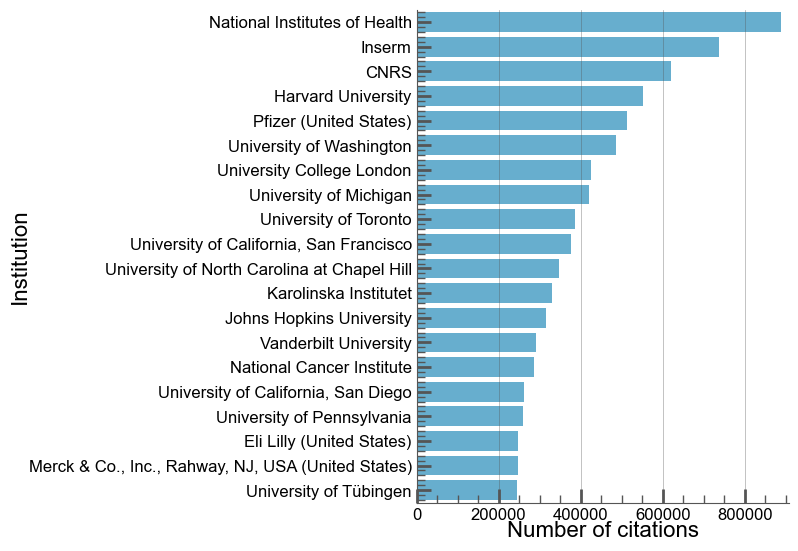

In [97]:
with aquarel.load_theme("scientific"):
    plt.figure(figsize=(4.8,6.4))
    sns.barplot(data = group_institutions_sum.head(n=20), x = "cited_by_count", y = "institution_simple", orient = "h")
    #plt.xticks(rotation = 90)
    plt.ylabel("Institution",fontsize=16)
    plt.xlabel("Number of citations", fontsize=16)
    plt.show()

In [69]:
group_institutions_sum_pandas

NameError: name 'group_institutions_sum_pandas' is not defined

In [49]:
group_institutions_sum

institution_simple,institution_name,count,cited_by_count,mncs
str,str,i32,i64,f64
"""National Institutes of Health""","""['National Institutes of Healt…",10088,889653,17231.435801
"""Inserm""","""['Inserm', 'https://openalex.o…",13341,738268,14797.780642
"""Centre National de la Recherch…","""['Centre National de la Recher…",10443,621029,11988.584457
"""Harvard University""","""['Harvard University', 'https:…",5795,550840,10565.898596
"""Pfizer (United States)""","""['Pfizer (United States)', 'ht…",6667,513982,9648.482292
…,…,…,…,…
"""Krankenhaus der Barmherzigen B…","""['Krankenhaus der Barmherzigen…",3,0,0.0
"""Robinson Brothers (United King…","""['Robinson Brothers (United Ki…",1,0,0.0
"""University of Energy and Natur…","""['University of Energy and Nat…",5,0,0.0


In [87]:
top_10_universities_names = ["Harvard University",
                       "University College London",
                       "University of Washington",
                       "University of Michigan",
                       "University of California, San Francisco",
                       "University of Toronto",
                       "Johns Hopkins University",
                       "University of California, San Diego",
                       "University of North Carolina at Chapel Hill",
                       "University of Pennsylvania"
                       ]

top_10_universities = (
    group_institutions_sum
    .filter(pl.col("institution_simple").is_in(top_10_universities_names))
)

#### N citations | N institutions

In [329]:
test = works[["cited_by_count", "institutions_distinct_count"]].groupby(by = "institutions_distinct_count").count()
test

,cited_by_count
institutions_distinct_count,
0,3978
1,10742
2,6036
3,2776
4,1275
5,603
6,274
7,156
8,88


<Figure size 640x480 with 0 Axes>

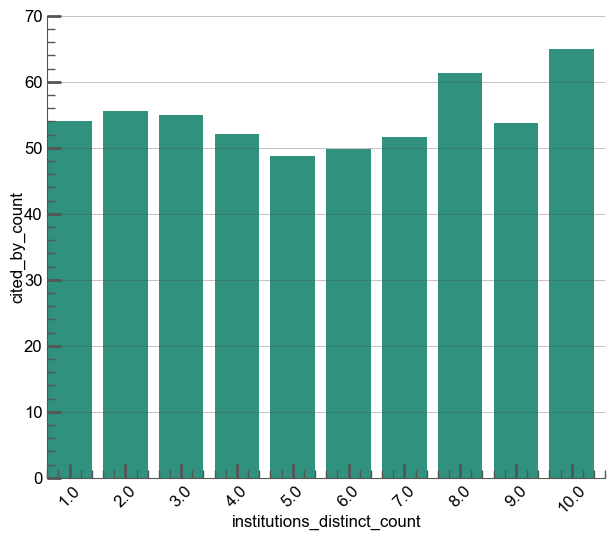

Mean authors count: 1.6212880589521028
Median authors count: 1.0


In [87]:

with aquarel.load_theme("scientific"):
    plt.figure(figsize=(7.2, 6))
    sns.barplot(data = group_Ninstitutions_mean, x = "institutions_distinct_count", y = "cited_by_count", color = sns.color_palette("viridis")[3])
    plt.xticks(rotation = 45)
    plt.xlim(0.6, 10.6)
    plt.ylim(0, 70)
    plt.show()

mean_value = works["institutions_distinct_count"].mean()
median_value = works["institutions_distinct_count"].median()
print(f"Mean authors count: {mean_value}")
print(f"Median authors count: {median_value}")

##### MNCS 

<Figure size 640x480 with 0 Axes>

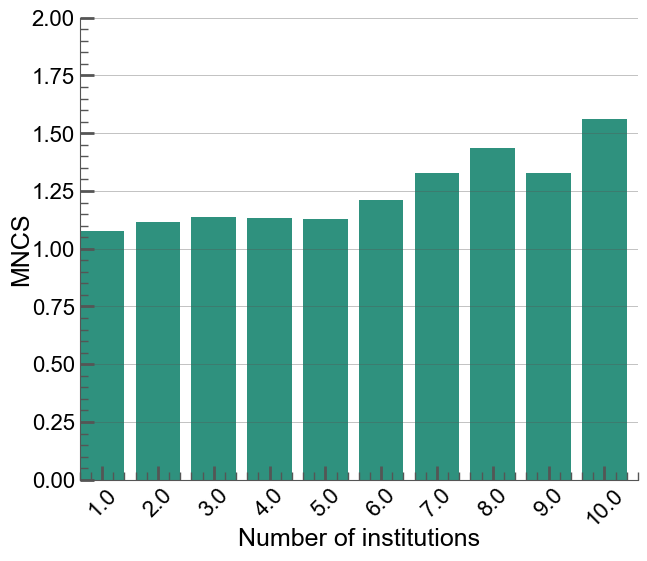

In [88]:

with aquarel.load_theme("scientific"):
    plt.figure(figsize=(7.2, 6))
    sns.barplot(data = group_Ninstitutions_mean, x = "institutions_distinct_count", y = "mncs", color = sns.color_palette("viridis")[3])
    plt.xticks(rotation = 45)
    plt.xlim(0.6, 10.6)
    plt.ylim(0, 2)
    plt.xlabel("Number of institutions", fontsize=18)
    plt.ylabel("MNCS", fontsize=18)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.show()


#### Study of big pharmas

In [82]:
bigpharma_names = ["Johnson & Johnson",
                    "Roche", 
                    "Merck", # ! Merck & co != Merck KgaA
                    "Pfizer", 
                    "AbbVie",
                    "AstraZeneca",
                    "Novartis", 
                    "Bristol-Myers Squibb",
                    "Eli Lilly",
                    "Sanofi",
                    "Novo Nordisk",
                    "GlaxoSmithKline",
                    "Amgen",
                    "Takeda",
                    "Boehringer Ingelheim",
                    "Gilead Sciences",
                    "Bayer",
                    "Teva Pharmaceuticals",
                    "CSL",
                    "BMS"
                    ] 
starts_with_expression = pl.col("institution_simple").str.starts_with(bigpharma_names[0])
for name in bigpharma_names[1:]:
    starts_with_expression =  starts_with_expression | pl.col("institution_simple").str.starts_with(name)

bigpharma = (
    institutions
    .filter(
        starts_with_expression
    )
    .with_columns(
        (pl.when(pl.col("institution_simple").str.starts_with("Bristol-Myers Squibb")).then(pl.lit("Bristol-Myers Squibb"))
        .otherwise(pl.col("institution_simple").str.replace_all(r"[(–\-)]", ",").str.split(",").list.get(0).str.strip_chars()) #warning: \ before the - otherwise regex think it's a range of character like a-z=alphabet
        .alias("institution_simple"))
    
    )
    .with_columns(
        (pl.when(pl.col("institution_simple").is_in(["Merck & Co.", "Merck Serono", "Merck Canada Inc.", "Merck Institute for Science Education"])).then(pl.lit("Merck"))
        .when(pl.col("institution_simple").is_in(["Pfizer-University of Granada-Junta de Andalucía Centre for Genomics and Oncological Research"])).then(pl.lit("Pfizer"))
        .when(pl.col("institution_simple").is_in(["Novartis Institutes for BioMedical Research", "Novartis Foundation"])).then(pl.lit("Novartis"))
        .when(pl.col("institution_simple").is_in(["Roche Pharma AG"])).then(pl.lit("Roche"))
        .when(pl.col("institution_simple").is_in(["Novo Nordisk Foundation"])).then(pl.lit("Novo Nordisk"))
        .otherwise(pl.col("institution_simple"))
        .alias("institution_simple"))
    
    )
)


In [83]:
bigpharma_pandas= bigpharma.to_pandas()
bigpharma_pandas

,year,index_work,cited_by_count,mncs,institution_pos,institution_name,count,institution_simple
0,1959,7295,7,0.190733,institution_1,"['Pfizer (United States)', 'https://openalex.o...",1,Pfizer
1,1959,7321,1,0.027248,institution_1,"['Pfizer (United States)', 'https://openalex.o...",1,Pfizer
2,1959,7366,16,0.435962,institution_1,"['Roche (Switzerland)', 'https://openalex.org/...",1,Roche
3,1960,7684,41,1.624685,institution_1,"['Roche (Switzerland)', 'https://openalex.org/...",1,Roche
4,1960,7736,3,0.118879,institution_1,"['Pfizer (United States)', 'https://openalex.o...",1,Pfizer
...,...,...,...,...,...,...,...,...
55524,2013,228755,146,2.195963,institution_192,"['GlaxoSmithKline (United Kingdom)', 'https://...",1,GlaxoSmithKline
55525,2016,253319,26,0.548614,institution_192,"['GlaxoSmithKline (United States)', 'https://o...",1,GlaxoSmithKline
55526,2016,255119,100,2.110053,institution_192,"['Merck & Co., Inc., Rahway, NJ, USA (United S...",1,Merck
55527,2017,263564,39,0.806891,institution_192,"['Bristol-Myers Squibb (United States)', 'http...",1,Bristol-Myers Squibb


In [84]:
errors = [
    "Rochester General Hospital",
    "Rochester Institute of Technology",
    "Bayero University Kano",
    "Bayerisches Landesamt für Gesundheit und Lebensmittelsicherheit"
]

group_bigpharma = (
    bigpharma
    .drop(["institution_name", "institution_pos"])
    .group_by(by = "institution_simple", maintain_order=True)
    .sum()
    .sort("cited_by_count", descending=True)
    .filter(~(pl.col("by").is_in(errors)))
)

group_bigpharma = group_bigpharma.with_columns(
    kind = pl.lit("Company"),
    institution_simple = pl.col("by")
).drop(["by", "index_work", "year"])

In [85]:
group_bigpharma_pandas = group_bigpharma.to_pandas()
group_bigpharma_pandas

,cited_by_count,mncs,count,institution_simple,kind
0,596395,11112.082815,7892,Pfizer,Company
1,356410,6031.911382,4459,GlaxoSmithKline,Company
2,354934,7150.293904,6394,Merck,Company
3,352854,7041.758995,6010,AstraZeneca,Company
4,330132,6281.056275,5057,Novartis,Company
5,275329,5225.256748,4432,Eli Lilly,Company
6,236544,4984.340264,4104,Roche,Company
7,194007,3881.352230,4127,Bristol-Myers Squibb,Company
8,112283,2334.559275,2084,Boehringer Ingelheim,Company
9,103795,1998.422209,1925,Amgen,Company


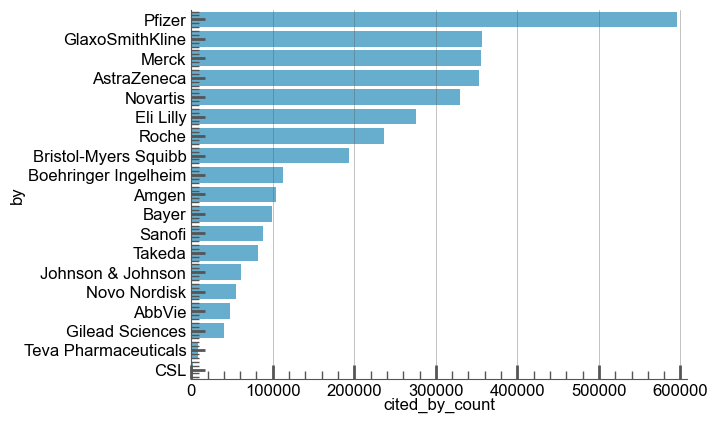

In [201]:
with aquarel.load_theme("scientific"):
    sns.barplot(data = group_bigpharma, x = "cited_by_count", y = "by", orient = "h",  legend = True)
    #plt.xticks(rotation = 90)
    plt.show()

#### Big pharma versus universities

In [79]:
group_national_institutions = group_institutions_sum[:][:3]

In [89]:
group_bigpharma

cited_by_count,mncs,count,institution_simple,kind
i64,f64,i32,str,str
596395,11112.082815,7892,"""Pfizer""","""Company"""
356410,6031.911382,4459,"""GlaxoSmithKline""","""Company"""
354934,7150.293904,6394,"""Merck""","""Company"""
352854,7041.758995,6010,"""AstraZeneca""","""Company"""
330132,6281.056275,5057,"""Novartis""","""Company"""
…,…,…,…,…
54905,1269.46396,833,"""Novo Nordisk""","""Company"""
47093,1384.92417,1286,"""AbbVie""","""Company"""
39959,1032.927702,821,"""Gilead Sciences""","""Company"""


In [91]:
top_10_universities

institution_simple,count,cited_by_count,mncs,kind
str,i32,i64,f64,str
"""Harvard University""",5795,550840,10565.898596,"""University"""
"""University of Washington""",5873,487018,9162.514138,"""University"""
"""University College London""",6158,424173,9531.626934,"""University"""
"""University of Michigan""",6606,420125,8234.214118,"""University"""
"""University of Toronto""",4859,385173,8745.387752,"""University"""
"""University of California, San …",5168,376321,7652.076688,"""University"""
"""University of North Carolina a…",5593,346830,6917.10247,"""University"""
"""Johns Hopkins University""",4195,315859,6737.888921,"""University"""
"""University of California, San …",3725,260758,5557.591629,"""University"""


In [103]:
impact_universities = top_10_universities["cited_by_count"].sum()/top_10_universities["count"].sum()
impact_bigpharma = group_bigpharma["cited_by_count"].sum()/group_bigpharma["count"].sum()
impact_national = group_national_institutions["cited_by_count"].sum()/ group_national_institutions["count"].sum()

In [104]:
print(impact_national)

66.39554794520548


In [105]:
print(impact_universities)

74.22183214694415


In [106]:
print(impact_bigpharma)

61.187380634932076


In [90]:
top_10_universities = top_10_universities.with_columns(
    kind = pl.lit("University")
).drop("institution_name")

In [92]:
group_national_institutions = group_national_institutions.drop("institution_name").with_columns(kind=pl.lit("National Institution"))

In [101]:
group_bigpharma = group_bigpharma.select(top_10_universities.columns)
top_20 = pl.concat([top_10_universities.head(n=7), group_bigpharma.head(n=6), group_national_institutions], how="vertical")
top_20 = top_20.sort("cited_by_count", descending=True)

C:\Users\gabri\AppData\Local\Temp\ipykernel_33492\2170650571.py:3: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  sns.barplot(data = top_20, x = "cited_by_count", y = "institution_simple", orient = "h", hue="kind", palette = palette, legend = True)


<Figure size 640x480 with 0 Axes>

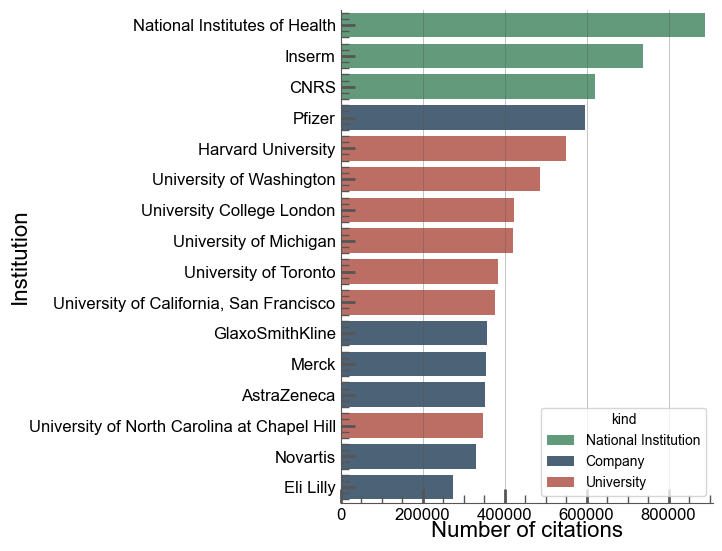

In [102]:
with aquarel.load_theme("scientific"):
    plt.figure(figsize=(4.8,6.4))
    sns.barplot(data = top_20, x = "cited_by_count", y = "institution_simple", orient = "h", hue="kind", palette = palette, legend = True)
    plt.xlabel("Number of citations", fontsize = 16)
    plt.ylabel("Institution", fontsize=16)
    plt.show()

## Counts by year 📆

In [249]:
means_yearly_citations = [works[f"cited_by_count_{i}"].mean() for i in range(2012, 2025)]

new_studies = works.filter(pl.col("year") == 2012)
means_2012_yearly_citations = [new_studies[f"cited_by_count_{i}"].mean() for i in range(2012, 2025)]

years = range(13)
years_2012 = range(2012, 2025)

list_means_yearly_citations = []
for year in years:
    new_studies = works.filter(pl.col("year") == 2012 + year)
    list_means_yearly_citations.append([new_studies[f"cited_by_count_{i}"].mean() for i in range(2012 + year, 2025)])

### Life of new studies VS part of life of older studies

<Figure size 640x480 with 0 Axes>

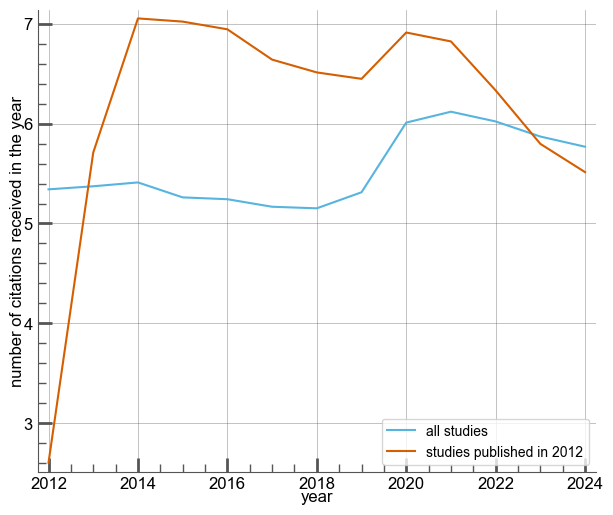

In [250]:
with aquarel.load_theme("scientific"):
    plt.figure(figsize=(7.2, 6))
    sns.lineplot(x = years_2012, y =  means_yearly_citations, label = "all studies")
    sns.lineplot(x = years_2012, y =  means_2012_yearly_citations, label = "studies published in 2012")
    plt.xlabel("year")
    plt.ylabel("number of citations received in the year")
    plt.legend()
    plt.show()

The number of citations is highest in the first year after publication of the article, which means that if there are more and more new articles, this will skew the "all studies" graph above.

### Number of studies per year and part of life of studies

In [259]:
number_studies_per_year = (
    works.with_columns(
        count = pl.lit(1)
    )
    .select(['year', 'count'])
    .group_by(by = "year")
    .sum()
    .sort(by = "by", descending=True)
)
number_studies_per_year = number_studies_per_year.filter(pl.col("by").is_in(years_2012))

In [260]:
means_yearly_citations_reduced = pd.Series(means_yearly_citations)
means_yearly_citations_reduced = (means_yearly_citations_reduced - means_yearly_citations_reduced.min())/(means_yearly_citations_reduced.max() - means_yearly_citations_reduced.min())
number_studies_per_year = number_studies_per_year["count"]
number_studies_per_year = (number_studies_per_year - number_studies_per_year.min())/(number_studies_per_year.max() - number_studies_per_year.min())

<Figure size 640x480 with 0 Axes>

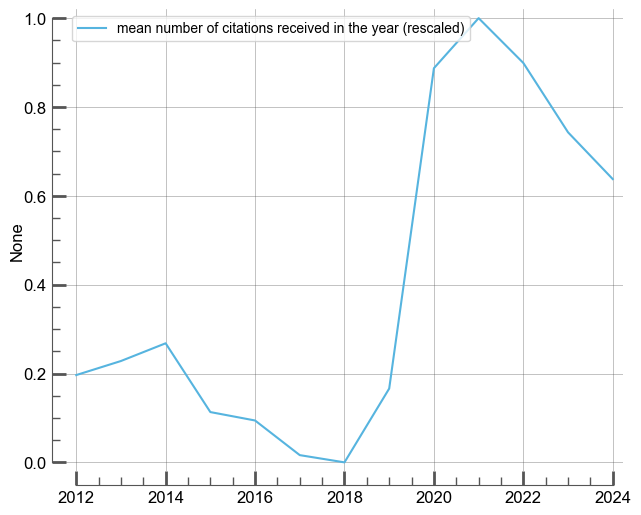

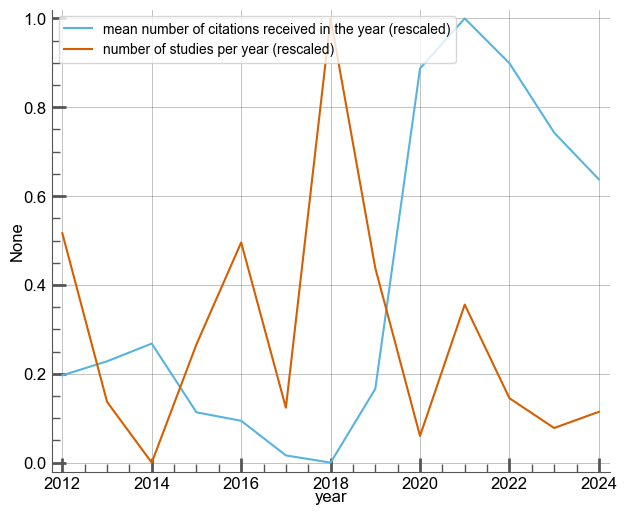

In [261]:
with aquarel.load_theme("scientific"):
    plt.figure(figsize=(7.2, 6))
    sns.lineplot(x = years_2012, y =  means_yearly_citations_reduced, label = "mean number of citations received in the year (rescaled)")
    sns.lineplot(x = years_2012, y = number_studies_per_year, label = "number of studies per year (rescaled)")
    plt.xlabel("year")
    plt.legend()
    plt.show()

We can see that the number of studies is tending to fall, invalidating the hypothesis of an advantageous bias.

### Begin of life of new studies according to the publication year

Studies published in 2021 and earlier seem to have reached a peak.

So of course we're blind to the future, but as we're looking at an average, it's unlikely that the average as a whole will rise again (although perhaps some studies will continue to rise).

<Figure size 640x480 with 0 Axes>

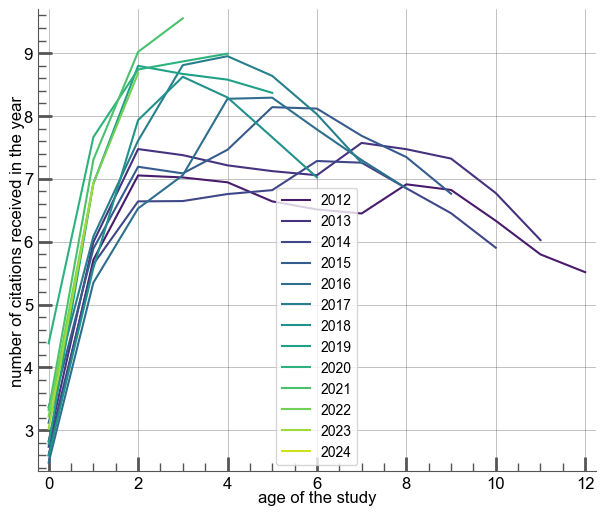

In [262]:
with aquarel.load_theme("scientific"):
    plt.figure(figsize=(7.2, 6))
    for i in range(13):
        y = list_means_yearly_citations[i]
        sns.lineplot(x = years[:len(y)], y = y, label = f"{2012 + i}", color = sns.set_palette("viridis", n_colors = 13))
    plt.xlabel("age of the study")
    plt.ylabel("number of citations received in the year")
    plt.legend()
    plt.show()

<Figure size 640x480 with 0 Axes>

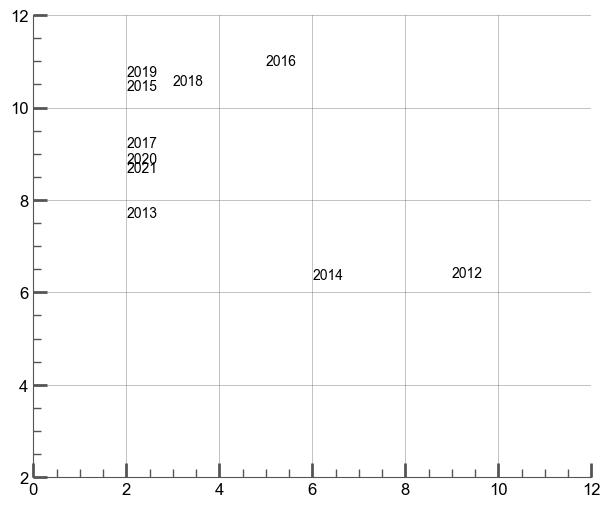

In [406]:
plt.figure(figsize=(7.2, 6))
for i in range(10):
    liste = pd.Series(list_means_yearly_citations[i])
    x = liste.argmax()
    y = liste.max()
    plt.text(x = x, y = y, s = f"{2012 + i}", fontweight = 50)
plt.xlim(0,12)
plt.ylim(2,12)
plt.show()

### Life of stars versus life of average publications

In [265]:
new_studies = works.filter(pl.col("year") == 2012)

In [266]:
new_studies

index_work,,title,year,cited_by_count,countries_distinct_count,institutions_distinct_count,citation_normalized_percentile,primary_topic,keywords,concepts,referenced_works_count,referenced_works,abstract,abstract_inverted_index,author_1,author_2,author_3,institution_1,country_1,cited_by_count_2025,cited_by_count_2024,cited_by_count_2023,cited_by_count_2022,cited_by_count_2021,cited_by_count_2020,cited_by_count_2019,cited_by_count_2018,cited_by_count_2017,cited_by_count_2016,cited_by_count_2015,cited_by_count_2014,cited_by_count_2013,cited_by_count_2012,primary_subfield,primary_field,primary_domain,…,country_162,country_163,country_164,country_165,keyword_13,country_166,country_167,country_168,country_169,country_170,country_171,country_172,country_173,country_174,country_175,country_176,country_177,country_178,country_179,country_180,country_181,country_182,country_183,country_184,country_185,country_186,country_187,country_188,country_189,country_190,country_191,country_192,age,mncs,authors_count,review,meta_analysis
u32,i64,str,i64,i64,i64,i64,str,str,str,str,i64,str,str,str,str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,…,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,f64,i8,bool,bool
217914,35,"""classification, functions, and…",2012,1641,2,2,"""{'value': 0.999734, 'is_in_top…","""('Extracellular vesicles in di…","""[{'id': 'https://openalex.org/…","""[{'id': 'https://openalex.org/…",341,"""['https://openalex.org/W125202…","""both eukaryotic and prokaryoti…","""{'Both': [0], 'eukaryotic': [1…","""https://openalex.org/A50720126…","""https://openalex.org/A51105410…","""https://openalex.org/A50807378…","""['Churchill Hospital', 'https:…","""GB""",47.0,129.0,131.0,161.0,182.0,181.0,176.0,147.0,152.0,123.0,98.0,74.0,29.0,4.0,"""('Molecular Biology',)""","""('Biochemistry, Genetics and M…","""('Life Sciences',)""",…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,13,28.063157,5,true,false
217915,54,"""brain-derived neurotrophic fac…",2012,1286,1,1,"""{'value': 0.99791, 'is_in_top_…","""('Autism Spectrum Disorder Res…","""[{'id': 'https://openalex.org/…","""[{'id': 'https://openalex.org/…",233,"""['https://openalex.org/W152703…","""brain derived neurotrophic fac…","""{'Brain': [0], 'derived': [1],…","""https://openalex.org/A50177002…","""https://openalex.org/A50553345…",null,"""['The University of Texas Sout…","""US""",43.0,99.0,95.0,100.0,115.0,113.0,140.0,121.0,95.0,110.0,78.0,81.0,62.0,30.0,"""('Cognitive Neuroscience',)""","""('Neuroscience',)""","""('Life Sciences',)""",…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,13,21.992212,2,true,false
217916,100,"""cisplatin resistance: a cellul…",2012,840,1,3,"""{'value': 0.997344, 'is_in_top…","""('Trace Elements in Health',)""","""[]""","""[{'id': 'https://openalex.org/…",145,"""['https://openalex.org/W145577…","""cisplatin is one of the most e…","""{'Cisplatin': [0], 'is': [1, 1…","""https://openalex.org/A51084997…","""https://openalex.org/A50405783…","""https://openalex.org/A50229240…","""['National Cancer Institute', …","""US""",27.0,64.0,73.0,91.0,96.0,77.0,67.0,67.0,84.0,55.0,58.0,53.0,18.0,7.0,"""('Nutrition and Dietetics',)""","""('Nursing',)""","""('Health Sciences',)""",…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,13,14.365053,4,false,false
217917,213,"""aldehyde dehydrogenase inhibit…",2012,524,2,6,"""{'value': 0.998778, 'is_in_top…","""('Alcohol Consumption and Heal…","""[{'id': 'https://openalex.org/…","""[{'id': 'https://openalex.org/…",182,"""['https://openalex.org/W101728…","""aldehyde dehydrogenases (aldhs

superstars = top 1% (85)
star = top 10% (852)

In [270]:
top_studies = new_studies.sort("cited_by_count", descending=True).with_row_index()
superstars = top_studies.filter(pl.col("index")<=85)
stars = top_studies.filter((pl.col("index")>85) & (pl.col("index")<=852))
usual = top_studies.filter(pl.col("index")>852)

In [271]:
superstars_2012_yearly_citations = pd.Series([superstars[f"cited_by_count_{i}"].mean() for i in range(2012, 2025)])
stars_2012_yearly_citations = pd.Series([stars[f"cited_by_count_{i}"].mean() for i in range(2012, 2025)])
usual_2012_yearly_citations = pd.Series([usual[f"cited_by_count_{i}"].mean() for i in range(2012, 2025)])

In [272]:
superstars_2012_yearly_citations = (superstars_2012_yearly_citations - superstars_2012_yearly_citations.min())/(superstars_2012_yearly_citations.max() - superstars_2012_yearly_citations.min())
stars_2012_yearly_citations = (stars_2012_yearly_citations - stars_2012_yearly_citations.min())/(stars_2012_yearly_citations.max() - stars_2012_yearly_citations.min())
usual_2012_yearly_citations = (usual_2012_yearly_citations - usual_2012_yearly_citations.min()) / (usual_2012_yearly_citations.max() - usual_2012_yearly_citations.min())

<Figure size 640x480 with 0 Axes>

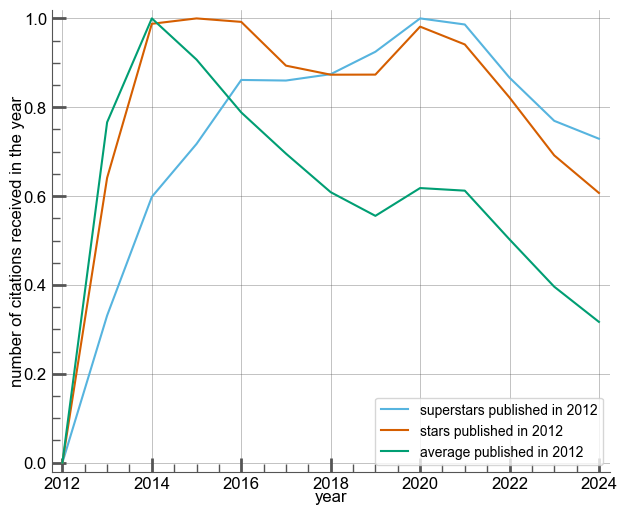

In [273]:
with aquarel.load_theme("scientific"):
    plt.figure(figsize=(7.2, 6))
    sns.lineplot(x = years_2012, y =  superstars_2012_yearly_citations, label = "superstars published in 2012")
    sns.lineplot(x = years_2012, y =  stars_2012_yearly_citations, label = "stars published in 2012")
    sns.lineplot(x = years_2012, y =  usual_2012_yearly_citations, label = "average published in 2012")
    plt.xlabel("year")
    plt.ylabel("number of citations received in the year")
    plt.legend()
    plt.show()

## Topics and keywords 🎭

### Topics from OpenAlex (old)

In [15]:
works_head = works.head()

In [14]:
works = works.with_columns(
    primary_topic = pl.col("primary_topic").str.replace("'","", literal=True, n=2).str.replace("(","", literal=True).str.replace(")","", literal=True).str.replace(",","", literal=True),
    primary_subfield = pl.col("primary_subfield").str.replace("'","", literal=True, n=2).str.replace("(","", literal=True).str.replace(")","", literal=True).str.replace(",","", literal=True),
    primary_field = pl.col("primary_field").str.replace("'","", literal=True, n=2).str.replace("(","", literal=True).str.replace(")","", literal=True).str.replace(",","", literal=True), 
    primary_domain = pl.col("primary_domain").str.replace("'","", literal=True, n=2).str.replace("(","", literal=True).str.replace(")","", literal=True).str.replace(",","", literal=True)
)


#### Covid

In [15]:
works_pandas = works.to_pandas()

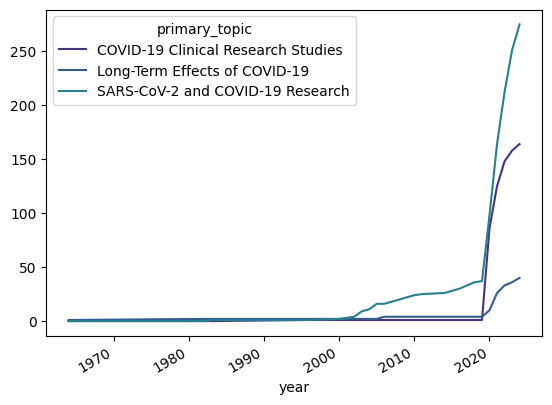

In [16]:
covid = (works_pandas[["primary_topic", "year", "title"]]).groupby(by = ["primary_topic", "year"]).count().reset_index()
covid  = covid[covid["primary_topic"].isin([
    "COVID-19 Clinical Research Studies", 
    "SARS-CoV-2 and COVID-19 Research",
    "Long-Term Effects of COVID-19"
    ])
    ]

topics_pivot = covid.pivot(index = "year", columns = "primary_topic", values = "title")
topics_pivot = topics_pivot.fillna(0)
topics_pivot = topics_pivot.cumsum(skipna = True)
topics_pivot = topics_pivot.sort_index()
topics_pivot.index = pd.to_datetime(topics_pivot.index, format ='%Y')
topics_pivot.plot()
plt.show()

#### Topics

In [17]:
group_topics = ((works_pandas)[works_pandas["year"]>2014][["primary_topic", "title"]]).groupby(by = "primary_topic").count()

In [18]:
group_topics.sort_values(by = "title", inplace = True, ascending = False)

C:\Users\gabri\AppData\Local\Temp\ipykernel_25048\333325213.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  primary_topics_merged = ' '.join((works_pandas_recent[works_pandas["primary_topic"].notna()])["primary_topic"])


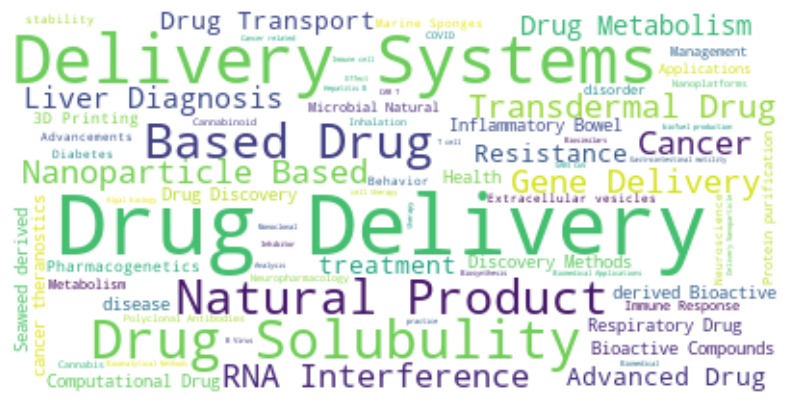

In [19]:
works_pandas_recent = works_pandas[works_pandas["year"]>2020]

# Data Cleaning and formatting
primary_topics_merged = ' '.join((works_pandas_recent[works_pandas["primary_topic"].notna()])["primary_topic"])
primary_topics_merged = primary_topics_merged.replace("Research", "")
primary_topics_merged = primary_topics_merged.replace("Treatment", "")
primary_topics_merged = primary_topics_merged.replace("Signaling", "")
primary_topics_merged = primary_topics_merged.replace("Disease", "")
primary_topics_merged = primary_topics_merged.replace("Mechanisms", "")
primary_topics_merged = primary_topics_merged.replace("research", "")
primary_topics_merged = primary_topics_merged.replace(" s ", "")
primary_topics_merged = primary_topics_merged.replace("Receptor", "")
primary_topics_merged = primary_topics_merged.replace("function", "")
primary_topics_merged = primary_topics_merged.replace("Studies", "")

wordcloud = wc.WordCloud(background_color= "white").generate(primary_topics_merged)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

#### Topics BCR cumulative

In [33]:
group_topics_bis = (works_pandas[["primary_topic", "year", "title"]]).groupby(by = ["primary_topic", "year"]).count().reset_index()
topics_pivot = group_topics_bis.pivot(index = "year", columns = "primary_topic", values = "title")
topics_pivot = topics_pivot.cumsum(skipna = True)
topics_pivot = topics_pivot.sort_index()
topics_pivot = topics_pivot.fillna(0)
topics_pivot.index = pd.to_datetime(topics_pivot.index, format ='%Y')

In [34]:
bcr.bar_chart_race(
    df=topics_pivot,
    filename='bar_chart_race.mp4',  # ou None pour afficher dans un notebook
    orientation='h',
    sort='desc',
    n_bars=5,
    fixed_order=False,
    fixed_max=True,
    steps_per_period=10,
    period_length=1000,
    period_fmt='%Y',
    title='Evolution of the top topics along the years',
    bar_size=.95,
    interpolate_period=True
)

c:\Users\gabri\AppData\Local\Programs\Python\Python313\Lib\site-packages\bar_chart_race\_make_chart.py:284: UserWarning: Glyph 127 () missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(io.BytesIO())
c:\Users\gabri\AppData\Local\Programs\Python\Python313\Lib\site-packages\bar_chart_race\_make_chart.py:284: UserWarning: Glyph 128 (\x80) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(io.BytesIO())
c:\Users\gabri\AppData\Local\Programs\Python\Python313\Lib\site-packages\bar_chart_race\_make_chart.py:284: UserWarning: Glyph 129 (\x81) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(io.BytesIO())
c:\Users\gabri\AppData\Local\Programs\Python\Python313\Lib\site-packages\bar_chart_race\_make_chart.py:284: UserWarning: Glyph 130 (\x82) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(io.BytesIO())
c:\Users\gabri\AppData\Local\Programs\Python\Python313\Lib\site-packages\bar_chart_race\_make_chart.py:284: UserWarning: Glyph 131 (\x83) missing from font

#### Topics BCR 5y-smoothing

In [35]:
smoothing = 5
group_topics_bis = (works_pandas[["primary_topic", "year", "title"]]).groupby(by = ["primary_topic", "year"]).count().reset_index()
topics_pivot = group_topics_bis.pivot(index = "year", columns = "primary_topic", values = "title")
topics_pivot = topics_pivot.fillna(0)
topics_pivot.drop(index=[1948, 1950], inplace=True)
topics_pivot_smooth = topics_pivot.copy()
for index, row in topics_pivot.iterrows():
    if index<1973:
        debut = 1968
    else:
        debut = index - smoothing
    topics_pivot_smooth.loc[index,:] = sum([topics_pivot.loc[i,:] for i in range(debut, index+1)])
    
topics_pivot_smooth = topics_pivot.sort_index()
topics_pivot_smooth.index = pd.to_datetime(topics_pivot.index, format ='%Y')

In [36]:
bcr.bar_chart_race(
    df=topics_pivot_smooth,
    filename='bar_chart_race_5ysmooth.mp4',  # ou None pour afficher dans un notebook
    orientation='h',
    sort='desc',
    n_bars=5,
    fixed_order=False,
    fixed_max=True,
    steps_per_period=10,
    period_length=2000,
    period_fmt='%Y',
    title='Evolution of the top topics along the years',
    bar_size=.95,
    interpolate_period=True
)

c:\Users\gabri\AppData\Local\Programs\Python\Python313\Lib\site-packages\bar_chart_race\_make_chart.py:284: UserWarning: Glyph 127 () missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(io.BytesIO())
c:\Users\gabri\AppData\Local\Programs\Python\Python313\Lib\site-packages\bar_chart_race\_make_chart.py:284: UserWarning: Glyph 128 (\x80) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(io.BytesIO())
c:\Users\gabri\AppData\Local\Programs\Python\Python313\Lib\site-packages\bar_chart_race\_make_chart.py:284: UserWarning: Glyph 129 (\x81) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(io.BytesIO())
c:\Users\gabri\AppData\Local\Programs\Python\Python313\Lib\site-packages\bar_chart_race\_make_chart.py:284: UserWarning: Glyph 130 (\x82) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(io.BytesIO())
c:\Users\gabri\AppData\Local\Programs\Python\Python313\Lib\site-packages\bar_chart_race\_make_chart.py:284: UserWarning: Glyph 131 (\x83) missing from font

#### Example of topics

In [37]:
topics_pivot = group_topics_bis.pivot(index = "year", columns = "primary_topic", values = "title")
topics_pivot = topics_pivot.cumsum(skipna = True)
topics_pivot = topics_pivot.sort_index()
topics_pivot = topics_pivot.ffill()
topics_pivot = topics_pivot.fillna(0)
topics_pivot = topics_pivot[[
    "Cannabis and Cannabinoid Research",
    "Asthma and respiratory diseases",
    "Pancreatic function and diabetes",
    "Regulation of Appetite and Obesity"
]]
topics_pivot

primary_topic,Cannabis and Cannabinoid Research,Asthma and respiratory diseases,Pancreatic function and diabetes,Regulation of Appetite and Obesity
year,,,,
1909,0.0,0.0,0.0,0.0
1910,0.0,0.0,0.0,0.0
1911,0.0,0.0,0.0,0.0
1912,0.0,0.0,0.0,0.0
1913,0.0,0.0,0.0,0.0
...,...,...,...,...
2020,2473.0,1606.0,1032.0,499.0
2021,2550.0,1619.0,1058.0,509.0
2022,2590.0,1631.0,1077.0,519.0


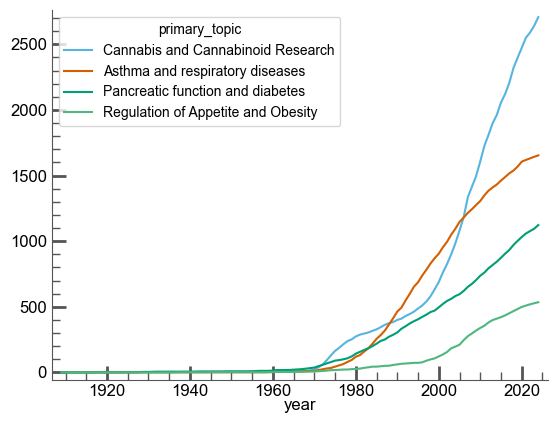

In [38]:
with aquarel.load_theme("scientific"):
    topics_pivot.plot()
    plt.show()

### Topics from Bertopic


In [77]:
works.write_parquet("works_pre_topics.parquet")

In [78]:
works.write_csv("works_pre_topics.csv")

#### Data preparation ⚒️

In [88]:
works_topics = pl.read_parquet("data_pharmacology/topics_pharma_1.0/works_post_topics.parquet")

In [90]:
topics_to_words = pl.read_csv("data_pharmacology/topics_pharma_1.0/topics_words.csv")

In [91]:
# number of works (for the next groupby)
works_topics = works_topics.with_columns(
    number_of_works = pl.lit(1)
)

In [92]:
cols = [f"cited_by_count_{i}" for i in range(2012, 2025)]
cols += ["topic", "mncs", "number_of_works", "year"]

In [93]:
# group by topics for quadrant

group_topics =  (
    works_topics.select(cols)
    .group_by("topic")
    .agg(
        pl.col("mncs").mean().alias("mncs"),
        pl.col("number_of_works").sum().alias("number_of_works"),
        *[pl.col(f"cited_by_count_{i}").mean().alias(f"cited_by_count_{i}") for i in range(2012, 2025)],
    )
)


In [94]:
group_topics_number_of_works = (
    works_topics.select("topic", "year", "number_of_works")
    .group_by(["topic", "year"])
    .sum()
    .filter(pl.col("year").is_in(range(2012, 2025)))
)

In [95]:
group_topics_number_of_works = group_topics_number_of_works.pivot(index="topic", on="year", values="number_of_works").sort("topic").rename(lambda x: f"number_of_works_{x}").rename({"number_of_works_topic": "topic"})

In [96]:
group_topics = group_topics.join(group_topics_number_of_works, on="topic").fill_null(0)

In [97]:
group_topics

topic,mncs,number_of_works,cited_by_count_2012,cited_by_count_2013,cited_by_count_2014,cited_by_count_2015,cited_by_count_2016,cited_by_count_2017,cited_by_count_2018,cited_by_count_2019,cited_by_count_2020,cited_by_count_2021,cited_by_count_2022,cited_by_count_2023,cited_by_count_2024,number_of_works_2015,number_of_works_2018,number_of_works_2019,number_of_works_2024,number_of_works_2020,number_of_works_2013,number_of_works_2014,number_of_works_2023,number_of_works_2021,number_of_works_2022,number_of_works_2017,number_of_works_2016,number_of_works_2012
i64,f64,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32
789,2.665454,48,12.25,15.0,13.25,15.882353,13.35,12.458333,10.75,12.384615,14.307692,12.413793,16.181818,19.058824,19.189189,2,4,1,4,3,4,3,4,2,3,2,5,1
932,0.345849,40,3.0,2.5,2.555556,2.125,1.875,1.7,1.5,1.6,2.5,1.142857,1.75,2.0,1.8,0,1,0,0,0,0,0,0,0,0,0,0,0
1197,1.498847,32,10.6,11.0,12.75,14.0,15.454545,10.8,12.357143,10.944444,12.8125,10.909091,9.851852,9.071429,9.740741,2,3,0,0,3,2,1,1,3,4,2,4,1
661,1.289865,57,8.466667,6.210526,6.444444,6.421053,5.894737,6.5625,6.277778,7.65,8.173913,8.548387,9.212121,9.0,8.666667,0,2,5,0,4,1,0,4,8,4,0,0,2
536,0.500725,70,4.615385,4.142857,4.6875,3.5,3.210526,3.966667,2.586207,3.029412,2.971429,3.133333,3.348837,2.851064,2.219512,6,3,8,5,8,4,1,2,8,1,3,4,1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
1298,0.620359,29,9.0,3.333333,4.5,6.875,4.222222,4.666667,3.307692,6.071429,4.0,4.666667,3.5,5.0,3.5,2,2,1,2,0,6,3,0,1,2,1,2,0
1959,1.091845,18,9.5,7.166667,8.5,7.333333,6.166667,4.25,5.857143,4.222222,5.2,6.125,4.181818,4.538462,4.166667,1,1,1,1,2,0,0,0,1,1,2,0,0
1828,1.184624,19,7.5,11.571429,10.375,7.7,6.7,5.916667,5.9,7.75,8.733333,7.692308,6.0,5.6875,5.428571,3,1,2,0,0,1,0,2,0,2,0,0,1


In [98]:
group_topicsyears =  (
    works_topics.select(["topic", "year", "mncs", "number_of_works"])
    .group_by(["topic", "year"])
    .sum()
    .sort("year")
    .with_columns(
        mncs=pl.col("mncs")/pl.col("number_of_works"),
        sum_cum_number_of_works=pl.col("number_of_works").cum_sum().over("topic") - pl.col("number_of_works")
    )
    .with_columns(
        sum_cum_mncs=pl.col("mncs").cum_sum().over("topic") - pl.col("mncs")
    )
    .with_columns(
        mean_cum_mncs=(pl.col("sum_cum_mncs")/pl.col("sum_cum_number_of_works")).fill_nan(1),
    )
)

In [99]:
topics_to_words_pandas = topics_to_words.to_pandas()

In [100]:
group_topics = group_topics.with_columns(
    word_1 = pl.col("topic").map_elements(lambda x: topics_to_words_pandas.loc[0, f"{x}"]),
    word_2 = pl.col("topic").map_elements(lambda x: topics_to_words_pandas.loc[1, f"{x}"]),
).with_columns(
    word_1 = pl.col("word_1").str.split(",").list.get(0).str.strip_chars(" ('"),
    word_2 = pl.col("word_2").str.split(",").list.get(0).str.strip_chars(" ('")  
).with_columns(
    topic_name = pl.col("word_1") + "_" + pl.col("word_2")
)

<sys>:0: MapWithoutReturnDtypeWarning:

Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.

<sys>:0: MapWithoutReturnDtypeWarning:

Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.



In [101]:
group_topics_pandas = group_topics.to_pandas()
group_topicsyears_pandas = group_topicsyears.to_pandas()


In [102]:
works_topics = works_topics.join(
    group_topics.select(["topic", "topic_name"]),
    on="topic",
    how="left"
)

#### Topics quadrant

wps_occ, that seems to be linked with clinical trial, is a clear outlier

C:\Users\gabri\AppData\Local\Temp\ipykernel_15612\3000710118.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gabri\AppData\Local\Temp\ipykernel_15612\3000710118.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gabri\AppData\Local\Temp\ipykernel_15612\3000710118.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/panda

<Figure size 640x480 with 0 Axes>

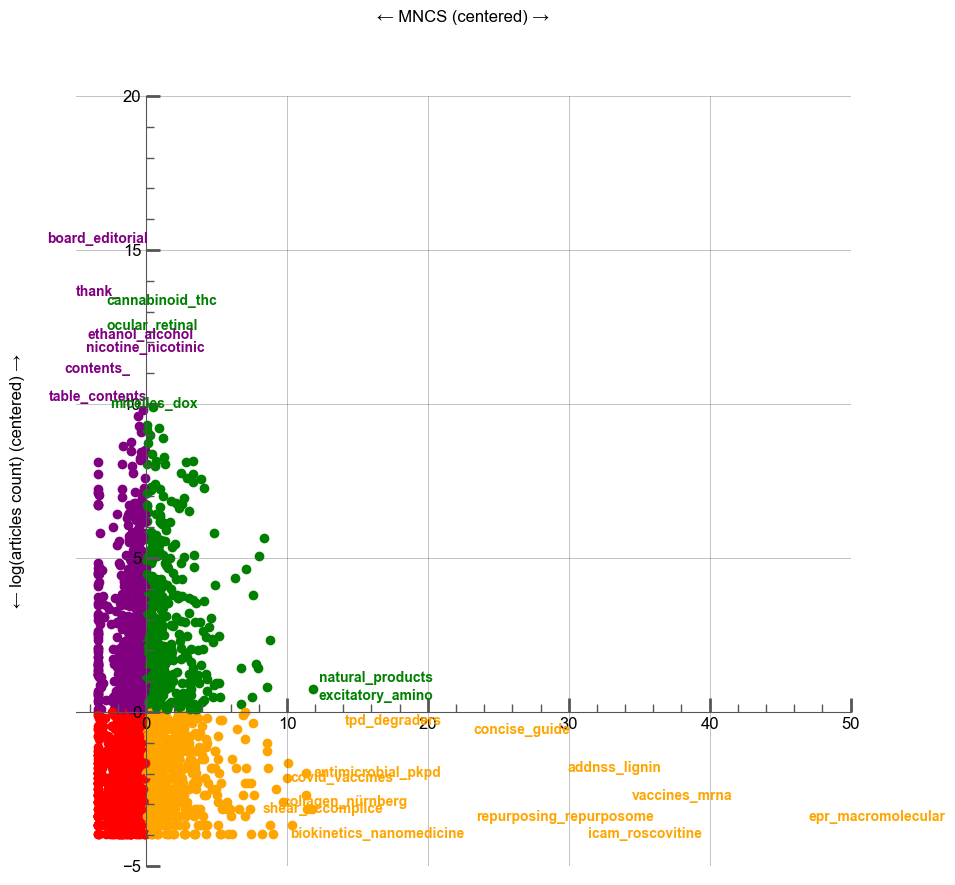

In [119]:
group_topics_viz = group_topics_pandas[group_topics_pandas["topic"]!=-1]
group_topics_viz["mncs_viz"] = (group_topics_viz["mncs"] -  group_topics_viz["mncs"].mean())/group_topics_viz["mncs"].std() *3
group_topics_viz["number_of_works_log"] = np.log(group_topics_viz["number_of_works"]) 
group_topics_viz["number_of_works_viz"] = (group_topics_viz["number_of_works_log"] -  group_topics_viz["number_of_works_log"].mean())/group_topics_viz["number_of_works_log"].std() *3

with aquarel.load_theme("scientific"):
    plt.figure(figsize = (10, 10))
for index, row in group_topics_viz.iterrows():
        if row["mncs_viz"] >= 0 and row["number_of_works_viz"] >= 0:
            color = "green"
        elif row["mncs_viz"] < 0 and row["number_of_works_viz"] >= 0:
            color = "purple"
        elif row["mncs_viz"] < 0 and row["number_of_works_viz"] < 0:
            color = "red"
        else:
            color = "orange"
        if row["mncs_viz"]>12 or row["number_of_works_viz"]>10:
            #3.0
            #if row["topic_name"] != "wps_occ":
            plt.text(row["mncs_viz"], row["number_of_works_viz"], row["topic_name"], ha = "center", va = "center", fontsize = 10, fontweight = "bold", color = color)
        else:
            plt.scatter(row["mncs_viz"], row["number_of_works_viz"],  color = color) 
plt.xlim(-5,50)
plt.ylim(-5,20)
plt.xlabel("← MNCS (centered) →", labelpad = - 520) # labelpad = décalage du label
plt.ylabel("← log(articles count) (centered) →", labelpad = 70)
# # position of the two axes
ax = plt.gca()
ax.spines['left'].set_position('zero')   # axe Y à x=0
ax.spines['bottom'].set_position('zero') # axe X à y=0

plt.show()

#### Preparation for modelling ⚒️

In [120]:
works_topics = (
    works_topics
    .sort("year")
    .join(
        group_topicsyears.select(["topic", "year", "sum_cum_number_of_works", "mean_cum_mncs"]),
        on=["topic", "year"],
        how="left"
    )
    .rename({
        "sum_cum_number_of_works": "past_contributions_topic",
        "mean_cum_mncs": "mean_past_mncs_topic"
    })
)

In [107]:
works_topics_pandas = works_topics.to_pandas() 

#### Citation share Inequalities | Size of the subfield

In [109]:
for i in range(0,258):
    works_topic = works_topics_pandas[works_topics_pandas["topic"] == i]
    group_topics_pandas.loc[i, "gini"] = gini(works_topic["cited_by_count"].values)


<Figure size 740x680 with 0 Axes>

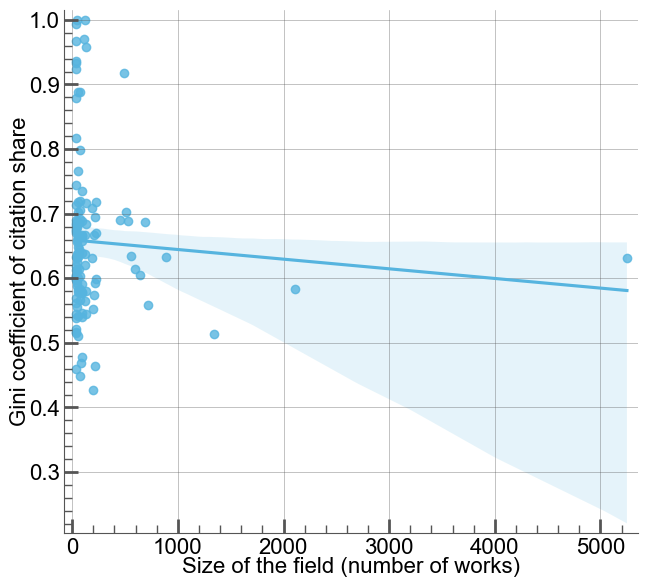

In [110]:
with aquarel.load_theme("scientific"):
    plt.figure(figsize=(7.4, 6.8))
    sns.regplot(data=group_topics_pandas[group_topics_pandas["number_of_works"]>30][1:], x="number_of_works", y="gini")
    plt.xlabel("Size of the field (number of works)", fontsize=16)
    plt.ylabel("Gini coefficient of citation share", fontsize=16)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.show()

#### BCR

In [115]:
works_topics_classified = works_topics.filter(~pl.col("topic").is_in([-1, 0, 1, 6, 7]))
group_topics_bcr = (
    works_topics_classified
    .select(["topic_name", "year", "mncs", "number_of_works", "cited_by_count", "topic"])
    .group_by(["topic_name", "year"])
    .agg(
        pl.col("number_of_works").sum().alias("number_of_works"),
        pl.col("cited_by_count").sum().alias("cited_by_count"),
        pl.col("topic")
    )
).fill_null(0)



In [116]:
smoothing = 5
group_topics_bcr_pandas = group_topics_bcr.to_pandas().dropna(subset=["topic_name"])
topics_pivot = group_topics_bcr_pandas.pivot(index = "year", columns = "topic_name", values = "number_of_works")
topics_pivot = topics_pivot.fillna(0)
topics_pivot_smooth = topics_pivot.copy()


In [117]:
for index, row in topics_pivot.iterrows():
    if index<1973:
        debut = 1968
    else:
        debut = index - smoothing
    topics_pivot_smooth.loc[index,:] = sum([topics_pivot.loc[i,:] for i in range(debut, index+1)])
    
topics_pivot_smooth = topics_pivot.sort_index()
topics_pivot_smooth.index = pd.to_datetime(topics_pivot.index, format ='%Y')

In [118]:
bcr.bar_chart_race(
    df=topics_pivot_smooth,
    filename='bcr_new.mp4',  # ou None pour afficher dans un notebook
    orientation='h',
    sort='desc',
    n_bars=5,
    fixed_order=False,
    fixed_max=True,
    steps_per_period=10,
    period_length=2000,
    period_fmt='%Y',
    title='Evolution of the top topics along the years',
    bar_size=.95,
    interpolate_period=True
)

Locator attempting to generate 11757 ticks ([-45.6, ..., 2305.6]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 11757 ticks ([-45.6, ..., 2305.6]), which exceeds Locator.MAXTICKS (1000).
c:\Users\gabri\AppData\Local\Programs\Python\Python313\Lib\site-packages\bar_chart_race\_make_chart.py:284: UserWarning:

Glyph 127 () missing from font(s) Arial.

c:\Users\gabri\AppData\Local\Programs\Python\Python313\Lib\site-packages\bar_chart_race\_make_chart.py:284: UserWarning:

Glyph 128 (\x80) missing from font(s) Arial.

c:\Users\gabri\AppData\Local\Programs\Python\Python313\Lib\site-packages\bar_chart_race\_make_chart.py:284: UserWarning:

Glyph 129 (\x81) missing from font(s) Arial.

c:\Users\gabri\AppData\Local\Programs\Python\Python313\Lib\site-packages\bar_chart_race\_make_chart.py:284: UserWarning:

Glyph 130 (\x82) missing from font(s) Arial.

c:\Users\gabri\AppData\Local\Programs\Python\Python313\Lib\site-packages\bar_chart_race\_make_chart.py:284: UserWarning

#### Topics evolutions quadrant

In [66]:
group_topics_test = group_topics_pandas[~group_topics_pandas["topic"].isin([-1,0])] 

In [67]:
group_topics_test = group_topics_test[group_topics_test["topic"].isin([1,2,3,4,5])]

In [68]:
group_topics_test = group_topics_test[group_topics_test["number_of_works_2024"]>=10]
for i in range(2012, 2025):
    
    group_topics_test[f"cited_by_count_{i}_viz"] = (group_topics_test[f"cited_by_count_{i}"] -  group_topics_test[f"cited_by_count_{i}"].mean())
    group_topics_test[f"number_of_works_{i}_log"] = group_topics_test[f"number_of_works_{i}"]
    group_topics_test[f"number_of_works_{i}_viz"] = (group_topics_test[f"number_of_works_{i}_log"] -  group_topics_test[f"number_of_works_{i}_log"].mean())

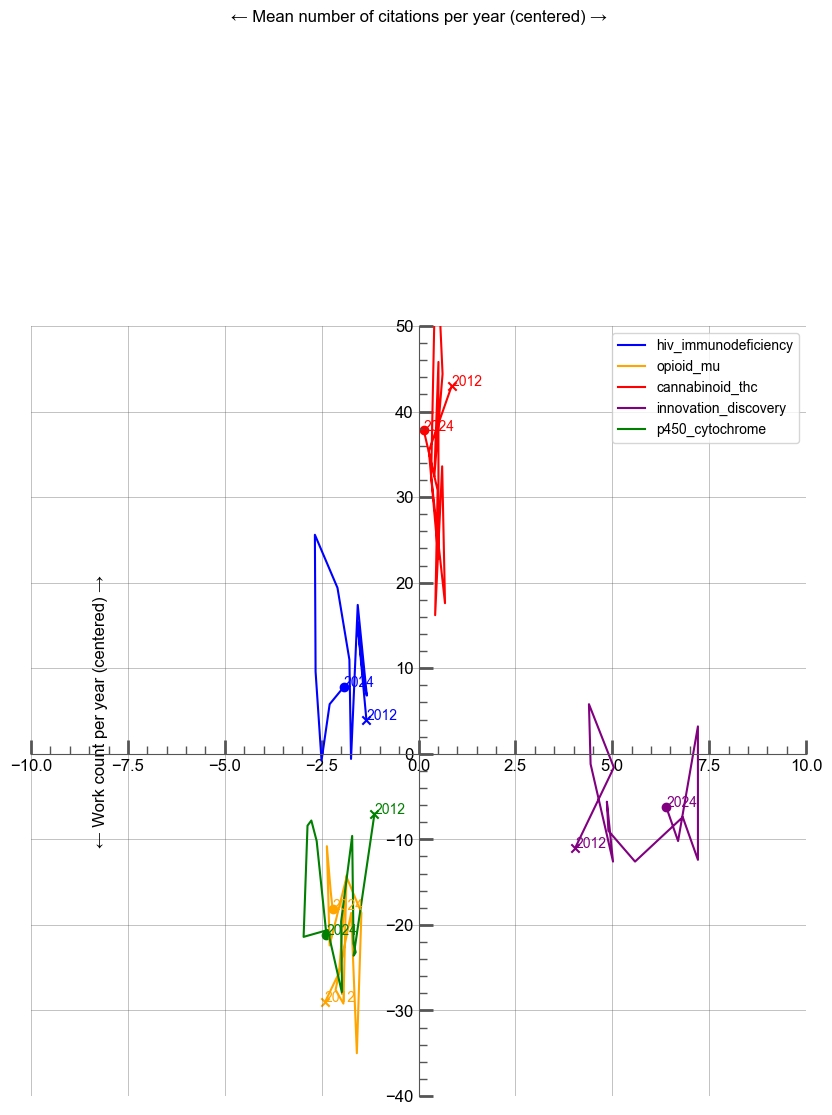

In [87]:
with aquarel.load_theme("scientific"):
    plt.figure(figsize = (10, 10))
    for index, row in group_topics_test.iterrows():
        if row["topic"] == 1:
            color="red"
        if row["topic"] == 2:
            color="green"
        if row["topic"] == 3:
            color = "blue"
        if row["topic"] == 4:
            color = "orange"
        if row["topic"] == 5:
            color = "purple"
        x = [row[f"cited_by_count_{i}_viz"] for i in range(2012, 2025)]
        y = [row[f"number_of_works_{i}_viz"] for i in range(2012, 2025)]
        plt.plot(x, y, color=color, label=row["topic_name"])
        plt.scatter(row["cited_by_count_2012_viz"], row["number_of_works_2012_viz"], marker="x", color=color)
        plt.scatter(row["cited_by_count_2024_viz"], row["number_of_works_2024_viz"],  color=color)
        plt.text(row["cited_by_count_2012_viz"], row["number_of_works_2012_viz"], "2012", color=color)
        plt.text(row["cited_by_count_2024_viz"], row["number_of_works_2024_viz"], "2024", color=color)  
        
    # plt.xlim(-20,40)
    # plt.ylim(-20,200)
    plt.xlim(-10,10)
    plt.ylim(-40,50)
    plt.xlabel("← Mean number of citations per year (centered) →", labelpad = - 550) # labelpad = décalage du label
    plt.ylabel("← Work count per year (centered) →", labelpad = 200)
    # # position of the two axes
    ax = plt.gca()
    ax.spines['left'].set_position('zero')   # axe Y à x=0
    ax.spines['bottom'].set_position('zero') # axe X à y=0
    plt.legend()
    plt.show()

## Heatmap and radar map 🌐

### Preparation for modelling ⚒️

In [126]:
works_modelling = works_topics.select([
    "year",
    "mncs",
    "countries_distinct_count",
    "institutions_distinct_count",
    "referenced_works_count",
    "authors_count",
    "review",
    "meta_analysis",
    "mean_past_contributions_authors",
    "mean_past_mncs_authors",
    "mean_past_contributions_institutions",
    "mean_past_mncs_institutions",
    "past_contributions_topic",
    "mean_past_mncs_topic",
])
works_modelling.write_parquet("data_pharmacology/works_modelling.parquet")

### Heatmap

In [122]:
works_quantitative = works_modelling.drop(["review", "meta_analysis"])

In [123]:
data_corr = works_quantitative.corr()
data_corr = data_corr.to_pandas()

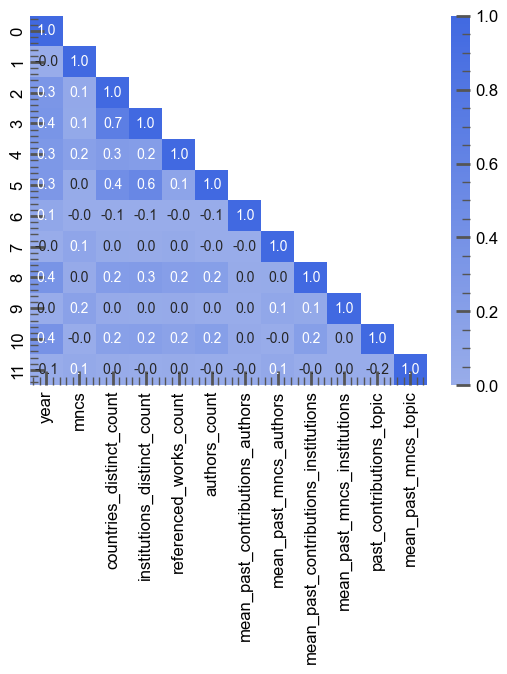

In [124]:
mask = np.triu(np.ones_like(data_corr, dtype=bool), k = 1)
cmap = sns.light_palette("royalblue", as_cmap=True)
sns.heatmap(data_corr, cmap = cmap, mask = mask, annot = True, fmt = ".1f", center = 0, vmin = 0, vmax = 1) #RdBu_r Spectral vlag
plt.grid(False)
plt.show()


### Radar map

In [80]:
works_quantitative = works_quantitative.to_pandas().sort_values(by="mncs", ascending=False)
stars = works_quantitative.loc[:3326,:].mean()
common = works_quantitative.loc[3326:,:].mean()  
summary = pd.concat([stars, common], axis = 1)
summary.reset_index(inplace = True)
summary.columns = ["feature", "top 10% works (MNCS)", "other works"]



In [81]:
summary = summary[~summary["feature"].isin(["cited_by_count", "mncs"])]

In [83]:
for index, row in summary.iterrows():
    summary.loc[index,"top 10% works (MNCS)"] =  (summary.loc[index,"top 10% works (MNCS)"] - (works_quantitative.loc[:, row["feature"]]).mean())/(works_quantitative.loc[:, row["feature"]]).std()
    summary.loc[index,"other works"] =  (summary.loc[index,"other works"] - (works_quantitative.loc[:, row["feature"]]).mean())/(works_quantitative.loc[:, row["feature"]]).std()

In [85]:
for index, row in summary.iterrows():
    summary.loc[index,"top 10% works (MNCS)"] =  (summary.loc[index,"top 10% works (MNCS)"] - (works_quantitative.loc[:, row["feature"]]).quantile(0))/ ((works_quantitative.loc[:, row["feature"]]).quantile(1) - (works_quantitative.loc[:, row["feature"]]).quantile(0))
    summary.loc[index,"other works"] =  (summary.loc[index,"other works"] - (works_quantitative.loc[:, row["feature"]]).quantile(0))/ ((works_quantitative.loc[:, row["feature"]]).quantile(1) - (works_quantitative.loc[:, row["feature"]]).quantile(0))

In [86]:
import plotly.express as px
# Transformation pour Plotly (format long)
summary_melt = summary.melt(id_vars='feature', var_name='Groupe', value_name='Valeur')
# Radar chart
fig = px.line_polar(
    summary_melt,
    r='Valeur',
    theta='feature',
    color='Groupe',
    line_close=True,
    markers=True
)

fig.update_traces(fill='toself')
fig.update_layout(title='Means of aggregated metadata (MinMax rescaled)')
fig.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, 1]  # Échelle de 0 à 1 par exemple
        )
    )
)
fig.update_layout(
    width=1000,  # Largeur
    height=600,  # Hauteur → même que la largeur pour un carré
)
fig.show()